In [ ]:
!pip -q install torch torchvision torchaudio scikit-learn seaborn pandas matplotlib pillow tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

ZIP_PATH = "/content/drive/MyDrive/Potato_Project/potato_uncontrolled.zip"

print("Zip exists:", os.path.exists(ZIP_PATH))
print("Zip path:", ZIP_PATH)

Zip exists: True
Zip path: /content/drive/MyDrive/Potato_Project/potato_uncontrolled.zip


In [ ]:
import zipfile
import os

EXTRACT_PATH = "/content/potato_uncontrolled"

# folder create kar do
os.makedirs(EXTRACT_PATH, exist_ok=True)

# unzip
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Unzipped successfully!")
print("Extracted to:", EXTRACT_PATH)

Unzipped successfully!
Extracted to: /content/potato_uncontrolled


In [ ]:
import os

print("Top-level folders/files:")
print(os.listdir(EXTRACT_PATH))

Top-level folders/files:
['Potato Leaf Disease Dataset in Uncontrolled Environment']


In [ ]:
for root, dirs, files in os.walk(EXTRACT_PATH):
    print("ROOT:", root)
    print("DIRS:", dirs[:10])
    print("FILES:", files[:5])
    print("-" * 60)
    break

ROOT: /content/potato_uncontrolled
DIRS: ['Potato Leaf Disease Dataset in Uncontrolled Environment']
FILES: []
------------------------------------------------------------


In [ ]:
import os

DATASET_ROOT = "/content/potato_uncontrolled/Potato Leaf Disease Dataset in Uncontrolled Environment"

print("Dataset root exists:", os.path.exists(DATASET_ROOT))
print("Dataset root path:", DATASET_ROOT)
print("\nItems inside dataset root:")
print(os.listdir(DATASET_ROOT))

Dataset root exists: True
Dataset root path: /content/potato_uncontrolled/Potato Leaf Disease Dataset in Uncontrolled Environment

Items inside dataset root:
['Fungi', 'Healthy', 'Phytopthora', 'Bacteria', 'Nematode', 'Pest', 'Virus']


In [ ]:
for item in os.listdir(DATASET_ROOT):
    item_path = os.path.join(DATASET_ROOT, item)
    if os.path.isdir(item_path):
        print(f"{item}  --->  FOLDER")
    else:
        print(f"{item}  --->  FILE")

Fungi  --->  FOLDER
Healthy  --->  FOLDER
Phytopthora  --->  FOLDER
Bacteria  --->  FOLDER
Nematode  --->  FOLDER
Pest  --->  FOLDER
Virus  --->  FOLDER


In [ ]:
for item in os.listdir(DATASET_ROOT):
    item_path = os.path.join(DATASET_ROOT, item)

    if os.path.isdir(item_path):
        print("=" * 60)
        print("PARENT FOLDER:", item)
        print("SUBITEMS:", os.listdir(item_path)[:20])

PARENT FOLDER: Fungi
SUBITEMS: ['20230802_112024.jpg', 'IMG_4672.JPG', 'IMG_9370.JPG', 'IMG_20230815_154600~2.jpg', 'IMG_0262.JPG', '20230802_112729.jpg', 'IMG_9436.JPG', '20230802_113011.jpg', 'IMG_8351.JPG', 'IMG_20230816_121459~2.jpg', '20230816_122721.jpg', '1692334247452.jpg', '20230802_110636.jpg', '20230802_111842612.jpg', '20230802_110219.jpg', 'IMG_4799.JPG', '20230802_110716.jpg', '20230802_112907.jpg', '20230802_110105.jpg', 'IMG_9393.JPG']
PARENT FOLDER: Healthy
SUBITEMS: ['20230712_123836.jpg', 'IMG_9417.JPG', 'IMG_1252.JPG', '20230816_115745.jpg', 'IMG_9473.JPG', '20230712_123812.jpg', '20230712_131219.jpg', '20230816_121149.jpg', '20230815_114115.jpg', '20230712_130703.jpg', '20230712_130758.jpg', '20230712_154114.jpg', 'IMG_0791.JPG', '20230815_120135.jpg', '20230712_131253.jpg', '20230802_113050671.jpg', '20230922_154136.jpg', 'IMG_20230815_120532~2.jpg', '20230712_130852.jpg', '20230922_155832.jpg']
PARENT FOLDER: Phytopthora
SUBITEMS: ['IMG_0366.JPG', 'IMG_0270 - Cop

In [ ]:
import os
import pandas as pd

ALLOWED_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

data = []

class_names = sorted([
    folder for folder in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, folder))
])

for class_name in class_names:
    class_folder = os.path.join(DATASET_ROOT, class_name)

    for file_name in os.listdir(class_folder):
        file_path = os.path.join(class_folder, file_name)

        if os.path.isfile(file_path) and file_name.lower().endswith(ALLOWED_EXTENSIONS):
            data.append({
                "filepath": file_path,
                "class_name": class_name
            })

df = pd.DataFrame(data)

print("DataFrame created successfully!")
print("Total images found:", len(df))
print("\nClass names:", class_names)

DataFrame created successfully!
Total images found: 3076

Class names: ['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']


In [ ]:
print(df.head())
print("\nClass distribution:\n")
print(df["class_name"].value_counts())

                                            filepath class_name
0  /content/potato_uncontrolled/Potato Leaf Disea...   Bacteria
1  /content/potato_uncontrolled/Potato Leaf Disea...   Bacteria
2  /content/potato_uncontrolled/Potato Leaf Disea...   Bacteria
3  /content/potato_uncontrolled/Potato Leaf Disea...   Bacteria
4  /content/potato_uncontrolled/Potato Leaf Disea...   Bacteria

Class distribution:

class_name
Fungi          748
Pest           611
Bacteria       569
Virus          532
Phytopthora    347
Healthy        201
Nematode        68
Name: count, dtype: int64


In [ ]:
from PIL import Image
from tqdm import tqdm

bad_files = []

for file_path in tqdm(df["filepath"].tolist(), desc="Checking images"):
    try:
        with Image.open(file_path) as img:
            img.verify()   # sirf verify karega, full load nahi
    except Exception:
        bad_files.append(file_path)

print("Total corrupted images found:", len(bad_files))

Checking images: 100%|██████████| 3076/3076 [00:00<00:00, 13595.27it/s]

Total corrupted images found: 0


In [ ]:
if len(bad_files) > 0:
    print("Some corrupted files:")
    for f in bad_files[:20]:
        print(f)
else:
    print("No corrupted images found.")

No corrupted images found.


In [ ]:
df_clean = df[~df["filepath"].isin(bad_files)].reset_index(drop=True)

print("Original images:", len(df))
print("Clean images   :", len(df_clean))
print("\nClean class distribution:\n")
print(df_clean["class_name"].value_counts())

Original images: 3076
Clean images   : 3076

Clean class distribution:

class_name
Fungi          748
Pest           611
Bacteria       569
Virus          532
Phytopthora    347
Healthy        201
Nematode        68
Name: count, dtype: int64


In [ ]:
class_names = sorted(df_clean["class_name"].unique())

class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

df_clean["label"] = df_clean["class_name"].map(class_to_idx)

print("Class to index mapping:")
print(class_to_idx)

print("\nSample data:")
print(df_clean.head())

Class to index mapping:
{'Bacteria': 0, 'Fungi': 1, 'Healthy': 2, 'Nematode': 3, 'Pest': 4, 'Phytopthora': 5, 'Virus': 6}

Sample data:
                                            filepath class_name  label
0  /content/potato_uncontrolled/Potato Leaf Disea...   Bacteria      0
1  /content/potato_uncontrolled/Potato Leaf Disea...   Bacteria      0
2  /content/potato_uncontrolled/Potato Leaf Disea...   Bacteria      0
3  /content/potato_uncontrolled/Potato Leaf Disea...   Bacteria      0
4  /content/potato_uncontrolled/Potato Leaf Disea...   Bacteria      0


In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# First split: train 70%, temp 30%
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    stratify=df_clean["label"],
    random_state=RANDOM_SEED
)

# Second split: temp ko val 15% + test 15% me divide karo
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train images:", len(train_df))
print("Val images  :", len(val_df))
print("Test images :", len(test_df))
print("Total check :", len(train_df) + len(val_df) + len(test_df))

Train images: 2153
Val images  : 461
Test images : 462
Total check : 3076


In [ ]:
print("Train class distribution:\n")
print(train_df["class_name"].value_counts())

print("\nVal class distribution:\n")
print(val_df["class_name"].value_counts())

print("\nTest class distribution:\n")
print(test_df["class_name"].value_counts())

Train class distribution:

class_name
Fungi          523
Pest           428
Bacteria       398
Virus          372
Phytopthora    243
Healthy        141
Nematode        48
Name: count, dtype: int64

Val class distribution:

class_name
Fungi          112
Pest            91
Bacteria        86
Virus           80
Phytopthora     52
Healthy         30
Nematode        10
Name: count, dtype: int64

Test class distribution:

class_name
Fungi          113
Pest            92
Bacteria        85
Virus           80
Phytopthora     52
Healthy         30
Nematode        10
Name: count, dtype: int64


In [ ]:
import pandas as pd

summary_df = pd.DataFrame({
    "Full": df_clean["class_name"].value_counts().sort_index(),
    "Train": train_df["class_name"].value_counts().sort_index(),
    "Val": val_df["class_name"].value_counts().sort_index(),
    "Test": test_df["class_name"].value_counts().sort_index(),
})

print(summary_df)

             Full  Train  Val  Test
class_name                         
Bacteria      569    398   86    85
Fungi         748    523  112   113
Healthy       201    141   30    30
Nematode       68     48   10    10
Pest          611    428   91    92
Phytopthora   347    243   52    52
Virus         532    372   80    80


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/Potato_Project/splits"
os.makedirs(SAVE_DIR, exist_ok=True)

train_df.to_csv(f"{SAVE_DIR}/train.csv", index=False)
val_df.to_csv(f"{SAVE_DIR}/val.csv", index=False)
test_df.to_csv(f"{SAVE_DIR}/test.csv", index=False)

print("CSV files saved successfully!")
print("Saved in:", SAVE_DIR)

CSV files saved successfully!
Saved in: /content/drive/MyDrive/Potato_Project/splits


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import numpy as np

# Baseline settings
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2
PIN_MEMORY = True if torch.cuda.is_available() else False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
IMG_SIZE: 224
BATCH_SIZE: 64


In [ ]:
class PotatoLeafDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "filepath"]
        label = int(self.dataframe.loc[idx, "label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms ready.")

Transforms ready.


In [ ]:
train_dataset = PotatoLeafDataset(train_df, transform=train_transform)
val_dataset   = PotatoLeafDataset(val_df, transform=val_test_transform)
test_dataset  = PotatoLeafDataset(test_df, transform=val_test_transform)

print("Train dataset size:", len(train_dataset))
print("Val dataset size  :", len(val_dataset))
print("Test dataset size :", len(test_dataset))

Train dataset size: 2153
Val dataset size  : 461
Test dataset size : 462


In [ ]:
train_labels = train_df["label"].values

class_sample_count = np.array([
    (train_labels == i).sum() for i in range(len(class_names))
])

class_weights = 1.0 / class_sample_count
sample_weights = np.array([class_weights[label] for label in train_labels])

sample_weights = torch.from_numpy(sample_weights).double()

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("Class sample count:", class_sample_count)
print("Class weights:", class_weights)

Class sample count: [398 523 141  48 428 243 372]
Class weights: [0.00251256 0.00191205 0.0070922  0.02083333 0.00233645 0.00411523
 0.00268817]


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Dataloaders created successfully!")
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Dataloaders created successfully!
Train batches: 34
Val batches  : 8
Test batches : 8


In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)
print("Image dtype       :", images.dtype)
print("Labels dtype      :", labels.dtype)
print("Sample labels     :", labels[:10].tolist())

Image batch shape : torch.Size([64, 3, 224, 224])
Label batch shape : torch.Size([64])
Image dtype       : torch.float32
Labels dtype      : torch.int64
Sample labels     : [1, 6, 5, 6, 0, 3, 6, 1, 0, 0]


In [ ]:
train_class_counts = train_df["label"].value_counts().sort_index().values
loss_class_weights = 1.0 / train_class_counts
loss_class_weights = loss_class_weights / loss_class_weights.sum() * len(loss_class_weights)

loss_class_weights_tensor = torch.tensor(loss_class_weights, dtype=torch.float32).to(device)

print("Loss class weights tensor:")
print(loss_class_weights_tensor)

Loss class weights tensor:
tensor([0.4239, 0.3226, 1.1966, 3.5149, 0.3942, 0.6943, 0.4535],
       device='cuda:0')


In [ ]:
from torchvision import models
from sklearn.metrics import f1_score
from tqdm.auto import tqdm
import copy
import time
import matplotlib.pyplot as plt

MODEL_SAVE_DIR = "/content/drive/MyDrive/Potato_Project/baseline_b0"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

BEST_B0_PATH = os.path.join(MODEL_SAVE_DIR, "best_efficientnet_b0.pth")
HISTORY_B0_PATH = os.path.join(MODEL_SAVE_DIR, "history_b0.csv")

print("Model save dir:", MODEL_SAVE_DIR)

Model save dir: /content/drive/MyDrive/Potato_Project/baseline_b0


In [ ]:
num_classes = len(class_names)

model_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

in_features = model_b0.classifier[1].in_features
model_b0.classifier = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(in_features, num_classes)
)

# Phase 1 ke liye backbone freeze
for param in model_b0.features.parameters():
    param.requires_grad = False

model_b0 = model_b0.to(device)

print(model_b0)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 165MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
criterion_b0 = nn.CrossEntropyLoss(
    weight=loss_class_weights_tensor,
    label_smoothing=0.05
)

optimizer_b0 = torch.optim.AdamW(
    model_b0.classifier.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scaler_b0 = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

print("Loss, optimizer, scaler ready.")

Loss, optimizer, scaler ready.


In [ ]:
def calculate_accuracy(outputs, labels):
    preds = torch.argmax(outputs, dim=1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct / total


def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    pbar = tqdm(loader, desc="Training", leave=False)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type=device.type, enabled=torch.cuda.is_available()):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * images.size(0)
        running_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples

    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation", leave=False)

        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type=device.type, enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion(outputs, labels)

            preds = torch.argmax(outputs, dim=1)

            running_loss += loss.item() * images.size(0)
            running_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, all_labels, all_preds


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
EPOCHS_B0_PHASE1 = 3

history_b0 = {
    "phase": [],
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "lr": []
}

best_val_f1_b0 = 0.0
best_val_acc_b0 = 0.0
best_epoch_b0 = -1

print("Trainable params in Phase 1:", count_trainable_params(model_b0))

Trainable params in Phase 1: 8967


In [ ]:
start_time = time.time()

for epoch in range(EPOCHS_B0_PHASE1):
    print("=" * 60)
    print(f"EfficientNet-B0 Phase 1 Epoch {epoch+1}/{EPOCHS_B0_PHASE1}")

    train_loss, train_acc = train_one_epoch(
        model_b0, train_loader, criterion_b0, optimizer_b0, scaler_b0, device
    )

    val_loss, val_acc, val_f1, _, _ = validate_one_epoch(
        model_b0, val_loader, criterion_b0, device
    )

    current_lr = optimizer_b0.param_groups[0]["lr"]

    history_b0["phase"].append("phase1_head_only")
    history_b0["epoch"].append(epoch + 1)
    history_b0["train_loss"].append(train_loss)
    history_b0["train_acc"].append(train_acc)
    history_b0["val_loss"].append(val_loss)
    history_b0["val_acc"].append(val_acc)
    history_b0["val_f1"].append(val_f1)
    history_b0["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1_b0:
        best_val_f1_b0 = val_f1
        best_val_acc_b0 = val_acc
        best_epoch_b0 = epoch + 1
        torch.save(model_b0.state_dict(), BEST_B0_PATH)
        print("Best model saved!")

phase1_time = time.time() - start_time

print("\nPhase 1 completed.")
print(f"Best Phase 1 Val Acc: {best_val_acc_b0:.4f}")
print(f"Best Phase 1 Val F1 : {best_val_f1_b0:.4f}")
print(f"Best Phase 1 Epoch  : {best_epoch_b0}")
print(f"Phase 1 Time        : {phase1_time/60:.2f} minutes")

EfficientNet-B0 Phase 1 Epoch 1/3


Training:   0%|          | 0/34 [00:00<?, ?it/s]

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Train Loss: 1.5880 | Train Acc: 0.1505
Val Loss  : 2.1168 | Val Acc  : 0.0304 | Val F1: 0.0282
Best model saved!
EfficientNet-B0 Phase 1 Epoch 2/3


Training:   0%|          | 0/34 [00:00<?, ?it/s]

...

Train Loss: 1.3089 | Train Acc: 0.2053
Val Loss  : 1.9532 | Val Acc  : 0.0824 | Val F1: 0.0912
Best model saved!
EfficientNet-B0 Phase 1 Epoch 3/3


Training:   0%|          | 0/34 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78fa4339c400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78fa4339c400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Train Loss: 1.1631 | Train Acc: 0.2810
Val Loss  : 1.7983 | Val Acc  : 0.1518 | Val F1: 0.1748
Best model saved!

Phase 1 completed.
Best Phase 1 Val Acc: 0.1518
Best Phase 1 Val F1 : 0.1748
Best Phase 1 Epoch  : 3
Phase 1 Time        : 2.35 minutes


In [ ]:
# FIXED DATALOADERS
NUM_WORKERS = 0
PIN_MEMORY = True if torch.cuda.is_available() else False

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,          # sampler hata diya
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Fixed dataloaders ready.")
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Fixed dataloaders ready.
Train batches: 34
Val batches  : 8
Test batches : 8


In [ ]:
from torchvision import models
import torch.nn as nn
import torch
import os
import pandas as pd
import time

num_classes = len(class_names)

model_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

in_features = model_b0.classifier[1].in_features
model_b0.classifier = nn.Sequential(
    nn.Dropout(0.30),
    nn.Linear(in_features, num_classes)
)

# head-only training
for param in model_b0.features.parameters():
    param.requires_grad = False

model_b0 = model_b0.to(device)

MODEL_SAVE_DIR = "/content/drive/MyDrive/Potato_Project/baseline_b0_fixed"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

BEST_B0_PATH = os.path.join(MODEL_SAVE_DIR, "best_efficientnet_b0_fixed.pth")
HISTORY_B0_PATH = os.path.join(MODEL_SAVE_DIR, "history_b0_fixed.csv")

print("Fresh B0 initialized.")

Fresh B0 initialized.


In [ ]:
criterion_b0 = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer_b0 = torch.optim.AdamW(
    model_b0.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scaler_b0 = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

history_b0 = {
    "phase": [],
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "lr": []
}

best_val_f1_b0 = 0.0
best_val_acc_b0 = 0.0
best_epoch_b0 = -1

print("Fresh loss/optimizer ready.")

Fresh loss/optimizer ready.


In [ ]:
EPOCHS_B0_PHASE1 = 2

start_time = time.time()

for epoch in range(EPOCHS_B0_PHASE1):
    print("=" * 60)
    print(f"EfficientNet-B0 Fixed Phase 1 Epoch {epoch+1}/{EPOCHS_B0_PHASE1}")

    train_loss, train_acc = train_one_epoch(
        model_b0, train_loader, criterion_b0, optimizer_b0, scaler_b0, device
    )

    val_loss, val_acc, val_f1, _, _ = validate_one_epoch(
        model_b0, val_loader, criterion_b0, device
    )

    current_lr = optimizer_b0.param_groups[0]["lr"]

    history_b0["phase"].append("phase1_head_only")
    history_b0["epoch"].append(epoch + 1)
    history_b0["train_loss"].append(train_loss)
    history_b0["train_acc"].append(train_acc)
    history_b0["val_loss"].append(val_loss)
    history_b0["val_acc"].append(val_acc)
    history_b0["val_f1"].append(val_f1)
    history_b0["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1_b0:
        best_val_f1_b0 = val_f1
        best_val_acc_b0 = val_acc
        best_epoch_b0 = epoch + 1
        torch.save(model_b0.state_dict(), BEST_B0_PATH)
        print("Best model saved!")

print("\nFixed Phase 1 completed.")
print(f"Best Val Acc: {best_val_acc_b0:.4f}")
print(f"Best Val F1 : {best_val_f1_b0:.4f}")
print(f"Best Epoch  : {best_epoch_b0}")

EfficientNet-B0 Fixed Phase 1 Epoch 1/2


Training:   0%|          | 0/34 [00:00<?, ?it/s]

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Train Loss: 1.6508 | Train Acc: 0.3878
Val Loss  : 1.4111 | Val Acc  : 0.5770 | Val F1: 0.4524
Best model saved!
EfficientNet-B0 Fixed Phase 1 Epoch 2/2


Training:   0%|          | 0/34 [00:00<?, ?it/s]

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Train Loss: 1.3519 | Train Acc: 0.5662
Val Loss  : 1.2571 | Val Acc  : 0.5987 | Val F1: 0.4889
Best model saved!

Fixed Phase 1 completed.
Best Val Acc: 0.5987
Best Val F1 : 0.4889
Best Epoch  : 2


In [ ]:
model_b0.load_state_dict(torch.load(BEST_B0_PATH))

for param in model_b0.features.parameters():
    param.requires_grad = True

optimizer_b0 = torch.optim.AdamW([
    {"params": model_b0.features.parameters(), "lr": 3e-5},
    {"params": model_b0.classifier.parameters(), "lr": 1e-4}
], weight_decay=1e-4)

scheduler_b0 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_b0,
    T_max=6
)

EPOCHS_B0_PHASE2 = 6
PATIENCE_B0 = 2
patience_counter_b0 = 0

print("Phase 2 ready.")

Phase 2 ready.


In [ ]:
start_time = time.time()

for epoch in range(EPOCHS_B0_PHASE2):
    print("=" * 60)
    print(f"EfficientNet-B0 Fixed Phase 2 Epoch {epoch+1}/{EPOCHS_B0_PHASE2}")

    train_loss, train_acc = train_one_epoch(
        model_b0, train_loader, criterion_b0, optimizer_b0, scaler_b0, device
    )

    val_loss, val_acc, val_f1, _, _ = validate_one_epoch(
        model_b0, val_loader, criterion_b0, device
    )

    scheduler_b0.step()
    current_lr = optimizer_b0.param_groups[0]["lr"]

    history_b0["phase"].append("phase2_full_finetune")
    history_b0["epoch"].append(epoch + 1)
    history_b0["train_loss"].append(train_loss)
    history_b0["train_acc"].append(train_acc)
    history_b0["val_loss"].append(val_loss)
    history_b0["val_acc"].append(val_acc)
    history_b0["val_f1"].append(val_f1)
    history_b0["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1_b0:
        best_val_f1_b0 = val_f1
        best_val_acc_b0 = val_acc
        best_epoch_b0 = epoch + 1
        patience_counter_b0 = 0
        torch.save(model_b0.state_dict(), BEST_B0_PATH)
        print("Best model updated and saved!")
    else:
        patience_counter_b0 += 1
        print(f"No improvement. Patience: {patience_counter_b0}/{PATIENCE_B0}")

    if patience_counter_b0 >= PATIENCE_B0:
        print("Early stopping triggered.")
        break

print("\nFixed Phase 2 completed.")
print(f"Best Overall Val Acc: {best_val_acc_b0:.4f}")
print(f"Best Overall Val F1 : {best_val_f1_b0:.4f}")
print(f"Best Overall Epoch  : {best_epoch_b0}")

EfficientNet-B0 Fixed Phase 2 Epoch 1/6


Training:   0%|          | 0/34 [00:00<?, ?it/s]

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Train Loss: 1.1909 | Train Acc: 0.6331
Val Loss  : 1.1062 | Val Acc  : 0.6659 | Val F1: 0.5873
Best model updated and saved!
EfficientNet-B0 Fixed Phase 2 Epoch 2/6


Training:   0%|          | 0/34 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Train Loss: 0.8553 | Train Acc: 0.7631
Val Loss  : 0.9042 | Val Acc  : 0.7397 | Val F1: 0.7128
Best model updated and saved!
EfficientNet-B0 Fixed Phase 2 Epoch 6/6


Training:   0%|          | 0/34 [00:00<?, ?it/s]

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Train Loss: 0.8443 | Train Acc: 0.7808
Val Loss  : 0.9002 | Val Acc  : 0.7440 | Val F1: 0.7134
Best model updated and saved!

Fixed Phase 2 completed.
Best Overall Val Acc: 0.7440
Best Overall Val F1 : 0.7134
Best Overall Epoch  : 6


In [ ]:
history_b0_df = pd.DataFrame(history_b0)
history_b0_df.to_csv(HISTORY_B0_PATH, index=False)

print("History saved:", HISTORY_B0_PATH)
history_b0_df.tail()

History saved: /content/drive/MyDrive/Potato_Project/baseline_b0_fixed/history_b0_fixed.csv


,phase,epoch,train_loss,train_acc,val_loss,val_acc,val_f1,lr
3,phase2_full_finetune,2,1.047500,0.689735,1.007132,0.700651,0.659613,0.000023
4,phase2_full_finetune,3,0.966095,0.713423,0.948196,0.715835,0.677088,0.000015
5,phase2_full_finetune,4,0.894014,0.757083,0.920096,0.737527,0.708659,0.000008
6,phase2_full_finetune,5,0.855344,0.763121,0.904226,0.739696,0.712844,0.000002
7,phase2_full_finetune,6,0.844282,0.780771,0.900216,0.744035,0.713392,0.000000


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

In [ ]:
num_classes = len(class_names)

model_b0_eval = models.efficientnet_b0(weights=None)

in_features = model_b0_eval.classifier[1].in_features
model_b0_eval.classifier = nn.Sequential(
    nn.Dropout(0.30),
    nn.Linear(in_features, num_classes)
)

model_b0_eval.load_state_dict(torch.load(BEST_B0_PATH, map_location=device))
model_b0_eval = model_b0_eval.to(device)
model_b0_eval.eval()

print("Best EfficientNet-B0 checkpoint loaded successfully.")

Best EfficientNet-B0 checkpoint loaded successfully.


In [ ]:
def evaluate_model(model, loader, device):
    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type=device.type, enabled=torch.cuda.is_available()):
                outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return acc, macro_f1, np.array(all_labels), np.array(all_preds)

In [ ]:
val_acc_b0, val_f1_b0, val_labels_b0, val_preds_b0 = evaluate_model(
    model_b0_eval, val_loader, device
)

test_acc_b0, test_f1_b0, test_labels_b0, test_preds_b0 = evaluate_model(
    model_b0_eval, test_loader, device
)

print("EfficientNet-B0 Final Evaluation")
print("=" * 50)
print(f"Validation Accuracy : {val_acc_b0:.4f}")
print(f"Validation Macro F1 : {val_f1_b0:.4f}")
print(f"Test Accuracy       : {test_acc_b0:.4f}")
print(f"Test Macro F1       : {test_f1_b0:.4f}")

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

EfficientNet-B0 Final Evaluation
Validation Accuracy : 0.7440
Validation Macro F1 : 0.7134
Test Accuracy       : 0.7359
Test Macro F1       : 0.7041


In [ ]:
print("Classification Report on Test Set:\n")
print(classification_report(
    test_labels_b0,
    test_preds_b0,
    target_names=class_names,
    digits=4
))

Classification Report on Test Set:

              precision    recall  f1-score   support

    Bacteria     0.8229    0.9294    0.8729        85
       Fungi     0.6949    0.7257    0.7100       113
     Healthy     0.6111    0.7333    0.6667        30
    Nematode     0.6667    0.4000    0.5000        10
        Pest     0.6667    0.5870    0.6243        92
 Phytopthora     0.8511    0.7692    0.8081        52
       Virus     0.7564    0.7375    0.7468        80

    accuracy                         0.7359       462
   macro avg     0.7243    0.6974    0.7041       462
weighted avg     0.7350    0.7359    0.7330       462



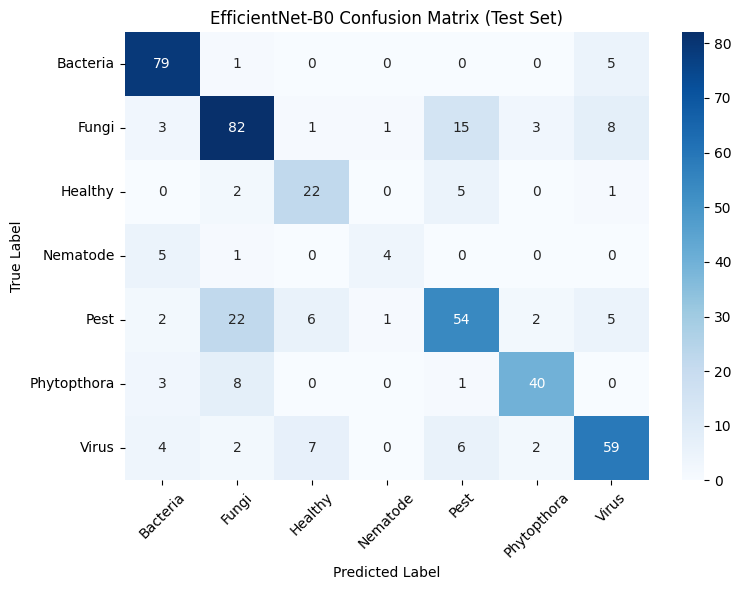

In [ ]:
cm_b0 = confusion_matrix(test_labels_b0, test_preds_b0)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_b0,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("EfficientNet-B0 Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
results_b0_df = pd.DataFrame({
    "Model": ["EfficientNet-B0"],
    "Val_Accuracy": [val_acc_b0],
    "Val_Macro_F1": [val_f1_b0],
    "Test_Accuracy": [test_acc_b0],
    "Test_Macro_F1": [test_f1_b0]
})

RESULTS_DIR = "/content/drive/MyDrive/Potato_Project/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

results_b0_path = os.path.join(RESULTS_DIR, "baseline_b0_results.csv")
results_b0_df.to_csv(results_b0_path, index=False)

print("Baseline B0 results saved at:")
print(results_b0_path)

results_b0_df

Baseline B0 results saved at:
/content/drive/MyDrive/Potato_Project/results/baseline_b0_results.csv


,Model,Val_Accuracy,Val_Macro_F1,Test_Accuracy,Test_Macro_F1
0,EfficientNet-B0,0.744035,0.713392,0.735931,0.704106


In [ ]:
from torchvision import models
import os
import pandas as pd
import time
import torch
import torch.nn as nn

MODEL_SAVE_DIR_D121 = "/content/drive/MyDrive/Potato_Project/baseline_densenet121"
os.makedirs(MODEL_SAVE_DIR_D121, exist_ok=True)

BEST_D121_PATH = os.path.join(MODEL_SAVE_DIR_D121, "best_densenet121.pth")
HISTORY_D121_PATH = os.path.join(MODEL_SAVE_DIR_D121, "history_densenet121.csv")

print("DenseNet121 save dir:", MODEL_SAVE_DIR_D121)

DenseNet121 save dir: /content/drive/MyDrive/Potato_Project/baseline_densenet121


In [ ]:
num_classes = len(class_names)

model_d121 = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

in_features = model_d121.classifier.in_features
model_d121.classifier = nn.Sequential(
    nn.Dropout(0.30),
    nn.Linear(in_features, num_classes)
)

# Phase 1: features freeze
for param in model_d121.features.parameters():
    param.requires_grad = False

model_d121 = model_d121.to(device)

print(model_d121)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 236MB/s]


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [ ]:
criterion_d121 = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer_d121 = torch.optim.AdamW(
    model_d121.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scaler_d121 = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

history_d121 = {
    "phase": [],
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "lr": []
}

best_val_f1_d121 = 0.0
best_val_acc_d121 = 0.0
best_epoch_d121 = -1

print("DenseNet121 loss/optimizer ready.")

DenseNet121 loss/optimizer ready.


In [ ]:
EPOCHS_D121_PHASE1 = 2

print("DenseNet121 Phase 1 epochs:", EPOCHS_D121_PHASE1)

DenseNet121 Phase 1 epochs: 2


In [ ]:
start_time = time.time()

for epoch in range(EPOCHS_D121_PHASE1):
    print("=" * 60)
    print(f"DenseNet121 Phase 1 Epoch {epoch+1}/{EPOCHS_D121_PHASE1}")

    train_loss, train_acc = train_one_epoch(
        model_d121, train_loader, criterion_d121, optimizer_d121, scaler_d121, device
    )

    val_loss, val_acc, val_f1, _, _ = validate_one_epoch(
        model_d121, val_loader, criterion_d121, device
    )

    current_lr = optimizer_d121.param_groups[0]["lr"]

    history_d121["phase"].append("phase1_head_only")
    history_d121["epoch"].append(epoch + 1)
    history_d121["train_loss"].append(train_loss)
    history_d121["train_acc"].append(train_acc)
    history_d121["val_loss"].append(val_loss)
    history_d121["val_acc"].append(val_acc)
    history_d121["val_f1"].append(val_f1)
    history_d121["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1_d121:
        best_val_f1_d121 = val_f1
        best_val_acc_d121 = val_acc
        best_epoch_d121 = epoch + 1
        torch.save(model_d121.state_dict(), BEST_D121_PATH)
        print("Best DenseNet121 model saved!")

print("\nDenseNet121 Phase 1 completed.")
print(f"Best Val Acc: {best_val_acc_d121:.4f}")
print(f"Best Val F1 : {best_val_f1_d121:.4f}")
print(f"Best Epoch  : {best_epoch_d121}")

DenseNet121 Phase 1 Epoch 1/2


Training:   0%|          | 0/34 [00:00<?, ?it/s]

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Train Loss: 1.6980 | Train Acc: 0.3432
Val Loss  : 1.4756 | Val Acc  : 0.5163 | Val F1: 0.3752
Best DenseNet121 model saved!
DenseNet121 Phase 1 Epoch 2/2


Training:   0%|          | 0/34 [00:00<?, ?it/s]

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Train Loss: 1.3902 | Train Acc: 0.5416
Val Loss  : 1.2740 | Val Acc  : 0.5965 | Val F1: 0.4489
Best DenseNet121 model saved!

DenseNet121 Phase 1 completed.
Best Val Acc: 0.5965
Best Val F1 : 0.4489
Best Epoch  : 2


In [ ]:
model_d121.load_state_dict(torch.load(BEST_D121_PATH, map_location=device))

for param in model_d121.features.parameters():
    param.requires_grad = True

optimizer_d121 = torch.optim.AdamW([
    {"params": model_d121.features.parameters(), "lr": 3e-5},
    {"params": model_d121.classifier.parameters(), "lr": 1e-4}
], weight_decay=1e-4)

scheduler_d121 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_d121,
    T_max=6
)

EPOCHS_D121_PHASE2 = 6
PATIENCE_D121 = 2
patience_counter_d121 = 0

print("DenseNet121 Phase 2 ready.")

DenseNet121 Phase 2 ready.


In [ ]:
start_time = time.time()

for epoch in range(EPOCHS_D121_PHASE2):
    print("=" * 60)
    print(f"DenseNet121 Phase 2 Epoch {epoch+1}/{EPOCHS_D121_PHASE2}")

    train_loss, train_acc = train_one_epoch(
        model_d121, train_loader, criterion_d121, optimizer_d121, scaler_d121, device
    )

    val_loss, val_acc, val_f1, _, _ = validate_one_epoch(
        model_d121, val_loader, criterion_d121, device
    )

    scheduler_d121.step()
    current_lr = optimizer_d121.param_groups[0]["lr"]

    history_d121["phase"].append("phase2_full_finetune")
    history_d121["epoch"].append(epoch + 1)
    history_d121["train_loss"].append(train_loss)
    history_d121["train_acc"].append(train_acc)
    history_d121["val_loss"].append(val_loss)
    history_d121["val_acc"].append(val_acc)
    history_d121["val_f1"].append(val_f1)
    history_d121["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1_d121:
        best_val_f1_d121 = val_f1
        best_val_acc_d121 = val_acc
        best_epoch_d121 = epoch + 1
        patience_counter_d121 = 0
        torch.save(model_d121.state_dict(), BEST_D121_PATH)
        print("Best DenseNet121 model updated and saved!")
    else:
        patience_counter_d121 += 1
        print(f"No improvement. Patience: {patience_counter_d121}/{PATIENCE_D121}")

    if patience_counter_d121 >= PATIENCE_D121:
        print("Early stopping triggered.")
        break

print("\nDenseNet121 Phase 2 completed.")
print(f"Best Overall Val Acc: {best_val_acc_d121:.4f}")
print(f"Best Overall Val F1 : {best_val_f1_d121:.4f}")
print(f"Best Overall Epoch  : {best_epoch_d121}")
print(f"Best model path     : {BEST_D121_PATH}")

DenseNet121 Phase 2 Epoch 1/6


Training:   0%|          | 0/34 [00:00<?, ?it/s]

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Train Loss: 1.1511 | Train Acc: 0.6354
Val Loss  : 1.0293 | Val Acc  : 0.7050 | Val F1: 0.6012
Best DenseNet121 model updated and saved!
DenseNet121 Phase 2 Epoch 2/6


Training:   0%|          | 0/34 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Train Loss: 0.6812 | Train Acc: 0.8412
Val Loss  : 0.7731 | Val Acc  : 0.7918 | Val F1: 0.7805
Best DenseNet121 model updated and saved!
DenseNet121 Phase 2 Epoch 6/6


Training:   0%|          | 0/34 [00:00<?, ?it/s]

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Train Loss: 0.6811 | Train Acc: 0.8435
Val Loss  : 0.7710 | Val Acc  : 0.7961 | Val F1: 0.7879
Best DenseNet121 model updated and saved!

DenseNet121 Phase 2 completed.
Best Overall Val Acc: 0.7961
Best Overall Val F1 : 0.7879
Best Overall Epoch  : 6
Best model path     : /content/drive/MyDrive/Potato_Project/baseline_densenet121/best_densenet121.pth


In [ ]:
history_d121_df = pd.DataFrame(history_d121)
history_d121_df.to_csv(HISTORY_D121_PATH, index=False)

print("DenseNet121 history saved:")
print(HISTORY_D121_PATH)

history_d121_df.tail()

DenseNet121 history saved:
/content/drive/MyDrive/Potato_Project/baseline_densenet121/history_densenet121.csv


,phase,epoch,train_loss,train_acc,val_loss,val_acc,val_f1,lr
3,phase2_full_finetune,2,0.939548,0.723177,0.890060,0.739696,0.656015,0.000023
4,phase2_full_finetune,3,0.811244,0.781235,0.821388,0.774403,0.743201,0.000015
5,phase2_full_finetune,4,0.726987,0.824431,0.796623,0.789588,0.758044,0.000008
6,phase2_full_finetune,5,0.681214,0.841152,0.773099,0.791757,0.780547,0.000002
7,phase2_full_finetune,6,0.681069,0.843474,0.770988,0.796095,0.787927,0.000000


In [ ]:
model_d121_eval = models.densenet121(weights=None)

in_features = model_d121_eval.classifier.in_features
model_d121_eval.classifier = nn.Sequential(
    nn.Dropout(0.30),
    nn.Linear(in_features, num_classes)
)

model_d121_eval.load_state_dict(torch.load(BEST_D121_PATH, map_location=device))
model_d121_eval = model_d121_eval.to(device)
model_d121_eval.eval()

print("Best DenseNet121 checkpoint loaded successfully.")

Best DenseNet121 checkpoint loaded successfully.


In [ ]:
val_acc_d121, val_f1_d121, val_labels_d121, val_preds_d121 = evaluate_model(
    model_d121_eval, val_loader, device
)

test_acc_d121, test_f1_d121, test_labels_d121, test_preds_d121 = evaluate_model(
    model_d121_eval, test_loader, device
)

print("DenseNet121 Final Evaluation")
print("=" * 50)
print(f"Validation Accuracy : {val_acc_d121:.4f}")
print(f"Validation Macro F1 : {val_f1_d121:.4f}")
print(f"Test Accuracy       : {test_acc_d121:.4f}")
print(f"Test Macro F1       : {test_f1_d121:.4f}")

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

DenseNet121 Final Evaluation
Validation Accuracy : 0.7961
Validation Macro F1 : 0.7879
Test Accuracy       : 0.7814
Test Macro F1       : 0.7437


In [ ]:
print("DenseNet121 Classification Report on Test Set:\n")
print(classification_report(
    test_labels_d121,
    test_preds_d121,
    target_names=class_names,
    digits=4
))

DenseNet121 Classification Report on Test Set:

              precision    recall  f1-score   support

    Bacteria     0.8367    0.9647    0.8962        85
       Fungi     0.7411    0.7345    0.7378       113
     Healthy     0.7273    0.8000    0.7619        30
    Nematode     0.5714    0.4000    0.4706        10
        Pest     0.7403    0.6196    0.6746        92
 Phytopthora     0.8913    0.7885    0.8367        52
       Virus     0.7865    0.8750    0.8284        80

    accuracy                         0.7814       462
   macro avg     0.7564    0.7403    0.7437       462
weighted avg     0.7787    0.7814    0.7769       462



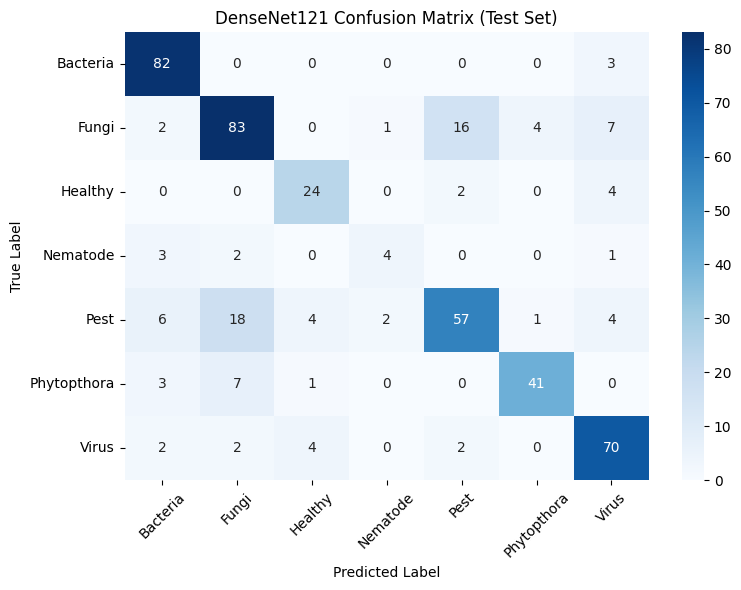

In [ ]:
cm_d121 = confusion_matrix(test_labels_d121, test_preds_d121)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_d121,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("DenseNet121 Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
results_d121_df = pd.DataFrame({
    "Model": ["DenseNet121"],
    "Val_Accuracy": [val_acc_d121],
    "Val_Macro_F1": [val_f1_d121],
    "Test_Accuracy": [test_acc_d121],
    "Test_Macro_F1": [test_f1_d121]
})

comparison_df = pd.concat([results_b0_df, results_d121_df], ignore_index=True)

comparison_path = "/content/drive/MyDrive/Potato_Project/results/b0_vs_densenet121.csv"
comparison_df.to_csv(comparison_path, index=False)

print("Comparison saved at:")
print(comparison_path)
comparison_df

Comparison saved at:
/content/drive/MyDrive/Potato_Project/results/b0_vs_densenet121.csv


,Model,Val_Accuracy,Val_Macro_F1,Test_Accuracy,Test_Macro_F1
0,EfficientNet-B0,0.744035,0.713392,0.735931,0.704106
1,DenseNet121,0.796095,0.787927,0.781385,0.743734


In [ ]:
IMG_SIZE_B2 = 260
BATCH_SIZE_B2 = 32
NUM_WORKERS_B2 = 0
PIN_MEMORY_B2 = True if torch.cuda.is_available() else False

print("IMG_SIZE_B2   :", IMG_SIZE_B2)
print("BATCH_SIZE_B2 :", BATCH_SIZE_B2)

IMG_SIZE_B2   : 260
BATCH_SIZE_B2 : 32


In [ ]:
train_transform_b2 = transforms.Compose([
    transforms.Resize((IMG_SIZE_B2, IMG_SIZE_B2)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform_b2 = transforms.Compose([
    transforms.Resize((IMG_SIZE_B2, IMG_SIZE_B2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("B2 transforms ready.")

B2 transforms ready.


In [ ]:
train_dataset_b2 = PotatoLeafDataset(train_df, transform=train_transform_b2)
val_dataset_b2   = PotatoLeafDataset(val_df, transform=val_test_transform_b2)
test_dataset_b2  = PotatoLeafDataset(test_df, transform=val_test_transform_b2)

print("Train dataset B2:", len(train_dataset_b2))
print("Val dataset B2  :", len(val_dataset_b2))
print("Test dataset B2 :", len(test_dataset_b2))

Train dataset B2: 2153
Val dataset B2  : 461
Test dataset B2 : 462


In [ ]:
train_loader_b2 = DataLoader(
    train_dataset_b2,
    batch_size=BATCH_SIZE_B2,
    shuffle=True,
    num_workers=NUM_WORKERS_B2,
    pin_memory=PIN_MEMORY_B2
)

val_loader_b2 = DataLoader(
    val_dataset_b2,
    batch_size=BATCH_SIZE_B2,
    shuffle=False,
    num_workers=NUM_WORKERS_B2,
    pin_memory=PIN_MEMORY_B2
)

test_loader_b2 = DataLoader(
    test_dataset_b2,
    batch_size=BATCH_SIZE_B2,
    shuffle=False,
    num_workers=NUM_WORKERS_B2,
    pin_memory=PIN_MEMORY_B2
)

print("B2 dataloaders ready.")
print("Train batches:", len(train_loader_b2))
print("Val batches  :", len(val_loader_b2))
print("Test batches :", len(test_loader_b2))

B2 dataloaders ready.
Train batches: 68
Val batches  : 15
Test batches : 15


In [ ]:
images_b2, labels_b2 = next(iter(train_loader_b2))

print("B2 image batch shape :", images_b2.shape)
print("B2 label batch shape :", labels_b2.shape)
print("B2 sample labels     :", labels_b2[:10].tolist())

B2 image batch shape : torch.Size([32, 3, 260, 260])
B2 label batch shape : torch.Size([32])
B2 sample labels     : [0, 0, 6, 4, 6, 4, 0, 4, 0, 1]


In [ ]:
MODEL_SAVE_DIR_B2 = "/content/drive/MyDrive/Potato_Project/baseline_b2"
os.makedirs(MODEL_SAVE_DIR_B2, exist_ok=True)

BEST_B2_PATH = os.path.join(MODEL_SAVE_DIR_B2, "best_efficientnet_b2.pth")
HISTORY_B2_PATH = os.path.join(MODEL_SAVE_DIR_B2, "history_b2.csv")

print("B2 save dir:", MODEL_SAVE_DIR_B2)

B2 save dir: /content/drive/MyDrive/Potato_Project/baseline_b2


In [ ]:
model_b2 = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)

in_features = model_b2.classifier[1].in_features
model_b2.classifier = nn.Sequential(
    nn.Dropout(0.35),
    nn.Linear(in_features, num_classes)
)

for param in model_b2.features.parameters():
    param.requires_grad = False

model_b2 = model_b2.to(device)

print(model_b2)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 238MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
criterion_b2 = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer_b2 = torch.optim.AdamW(
    model_b2.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scaler_b2 = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

history_b2 = {
    "phase": [],
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "lr": []
}

best_val_f1_b2 = 0.0
best_val_acc_b2 = 0.0
best_epoch_b2 = -1

print("B2 loss/optimizer ready.")

B2 loss/optimizer ready.


In [ ]:
EPOCHS_B2_PHASE1 = 2

for epoch in range(EPOCHS_B2_PHASE1):
    print("=" * 60)
    print(f"EfficientNet-B2 Phase 1 Epoch {epoch+1}/{EPOCHS_B2_PHASE1}")

    train_loss, train_acc = train_one_epoch(
        model_b2, train_loader_b2, criterion_b2, optimizer_b2, scaler_b2, device
    )

    val_loss, val_acc, val_f1, _, _ = validate_one_epoch(
        model_b2, val_loader_b2, criterion_b2, device
    )

    current_lr = optimizer_b2.param_groups[0]["lr"]

    history_b2["phase"].append("phase1_head_only")
    history_b2["epoch"].append(epoch + 1)
    history_b2["train_loss"].append(train_loss)
    history_b2["train_acc"].append(train_acc)
    history_b2["val_loss"].append(val_loss)
    history_b2["val_acc"].append(val_acc)
    history_b2["val_f1"].append(val_f1)
    history_b2["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1_b2:
        best_val_f1_b2 = val_f1
        best_val_acc_b2 = val_acc
        best_epoch_b2 = epoch + 1
        torch.save(model_b2.state_dict(), BEST_B2_PATH)
        print("Best B2 model saved!")

print("\nB2 Phase 1 completed.")
print(f"Best Val Acc: {best_val_acc_b2:.4f}")
print(f"Best Val F1 : {best_val_f1_b2:.4f}")
print(f"Best Epoch  : {best_epoch_b2}")

EfficientNet-B2 Phase 1 Epoch 1/2


Training:   0%|          | 0/68 [00:00<?, ?it/s]

Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss: 1.5647 | Train Acc: 0.4422
Val Loss  : 1.3278 | Val Acc  : 0.6052 | Val F1: 0.4664
Best B2 model saved!
EfficientNet-B2 Phase 1 Epoch 2/2


Training:   0%|          | 0/68 [00:00<?, ?it/s]

Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss: 1.2531 | Train Acc: 0.6052
Val Loss  : 1.1896 | Val Acc  : 0.6334 | Val F1: 0.5091
Best B2 model saved!

B2 Phase 1 completed.
Best Val Acc: 0.6334
Best Val F1 : 0.5091
Best Epoch  : 2


In [ ]:
model_b2.load_state_dict(torch.load(BEST_B2_PATH, map_location=device))

for param in model_b2.features.parameters():
    param.requires_grad = True

optimizer_b2 = torch.optim.AdamW([
    {"params": model_b2.features.parameters(), "lr": 3e-5},
    {"params": model_b2.classifier.parameters(), "lr": 1e-4}
], weight_decay=1e-4)

scheduler_b2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_b2,
    T_max=6
)

EPOCHS_B2_PHASE2 = 6
PATIENCE_B2 = 2
patience_counter_b2 = 0

print("B2 Phase 2 ready.")

B2 Phase 2 ready.


In [ ]:
for epoch in range(EPOCHS_B2_PHASE2):
    print("=" * 60)
    print(f"EfficientNet-B2 Phase 2 Epoch {epoch+1}/{EPOCHS_B2_PHASE2}")

    train_loss, train_acc = train_one_epoch(
        model_b2, train_loader_b2, criterion_b2, optimizer_b2, scaler_b2, device
    )

    val_loss, val_acc, val_f1, _, _ = validate_one_epoch(
        model_b2, val_loader_b2, criterion_b2, device
    )

    scheduler_b2.step()
    current_lr = optimizer_b2.param_groups[0]["lr"]

    history_b2["phase"].append("phase2_full_finetune")
    history_b2["epoch"].append(epoch + 1)
    history_b2["train_loss"].append(train_loss)
    history_b2["train_acc"].append(train_acc)
    history_b2["val_loss"].append(val_loss)
    history_b2["val_acc"].append(val_acc)
    history_b2["val_f1"].append(val_f1)
    history_b2["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1_b2:
        best_val_f1_b2 = val_f1
        best_val_acc_b2 = val_acc
        best_epoch_b2 = epoch + 1
        patience_counter_b2 = 0
        torch.save(model_b2.state_dict(), BEST_B2_PATH)
        print("Best B2 model updated and saved!")
    else:
        patience_counter_b2 += 1
        print(f"No improvement. Patience: {patience_counter_b2}/{PATIENCE_B2}")

    if patience_counter_b2 >= PATIENCE_B2:
        print("Early stopping triggered.")
        break

print("\nB2 Phase 2 completed.")
print(f"Best Overall Val Acc: {best_val_acc_b2:.4f}")
print(f"Best Overall Val F1 : {best_val_f1_b2:.4f}")
print(f"Best Overall Epoch  : {best_epoch_b2}")

EfficientNet-B2 Phase 2 Epoch 1/6


Training:   0%|          | 0/68 [00:00<?, ?it/s]

Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss: 1.0703 | Train Acc: 0.6786
Val Loss  : 0.9648 | Val Acc  : 0.7180 | Val F1: 0.6611
Best B2 model updated and saved!
EfficientNet-B2 Phase 2 Epoch 2/6


Training:   0%|          | 0/68 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss: 0.6700 | Train Acc: 0.8402
Val Loss  : 0.7780 | Val Acc  : 0.7983 | Val F1: 0.7702
No improvement. Patience: 1/2
EfficientNet-B2 Phase 2 Epoch 6/6


Training:   0%|          | 0/68 [00:00<?, ?it/s]

Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss: 0.6533 | Train Acc: 0.8416
Val Loss  : 0.7634 | Val Acc  : 0.7874 | Val F1: 0.7559
No improvement. Patience: 2/2
Early stopping triggered.

B2 Phase 2 completed.
Best Overall Val Acc: 0.7983
Best Overall Val F1 : 0.7717
Best Overall Epoch  : 4


In [ ]:
history_b2_df = pd.DataFrame(history_b2)
history_b2_df.to_csv(HISTORY_B2_PATH, index=False)

model_b2_eval = models.efficientnet_b2(weights=None)
in_features = model_b2_eval.classifier[1].in_features
model_b2_eval.classifier = nn.Sequential(
    nn.Dropout(0.35),
    nn.Linear(in_features, num_classes)
)

model_b2_eval.load_state_dict(torch.load(BEST_B2_PATH, map_location=device))
model_b2_eval = model_b2_eval.to(device)
model_b2_eval.eval()

val_acc_b2, val_f1_b2, _, _ = evaluate_model(model_b2_eval, val_loader_b2, device)
test_acc_b2, test_f1_b2, test_labels_b2, test_preds_b2 = evaluate_model(model_b2_eval, test_loader_b2, device)

print("EfficientNet-B2 Final Evaluation")
print("=" * 50)
print(f"Validation Accuracy : {val_acc_b2:.4f}")
print(f"Validation Macro F1 : {val_f1_b2:.4f}")
print(f"Test Accuracy       : {test_acc_b2:.4f}")
print(f"Test Macro F1       : {test_f1_b2:.4f}")

Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]

EfficientNet-B2 Final Evaluation
Validation Accuracy : 0.7983
Validation Macro F1 : 0.7717
Test Accuracy       : 0.7965
Test Macro F1       : 0.7490


In [ ]:
results_b2_df = pd.DataFrame({
    "Model": ["EfficientNet-B2"],
    "Val_Accuracy": [val_acc_b2],
    "Val_Macro_F1": [val_f1_b2],
    "Test_Accuracy": [test_acc_b2],
    "Test_Macro_F1": [test_f1_b2]
})

comparison_all_df = pd.concat([results_b0_df, results_d121_df, results_b2_df], ignore_index=True)
comparison_all_df = comparison_all_df.sort_values(by="Val_Macro_F1", ascending=False).reset_index(drop=True)

comparison_all_path = "/content/drive/MyDrive/Potato_Project/results/all_baselines_comparison.csv"
comparison_all_df.to_csv(comparison_all_path, index=False)

print("All baseline comparison saved at:")
print(comparison_all_path)
comparison_all_df

All baseline comparison saved at:
/content/drive/MyDrive/Potato_Project/results/all_baselines_comparison.csv


,Model,Val_Accuracy,Val_Macro_F1,Test_Accuracy,Test_Macro_F1
0,DenseNet121,0.796095,0.787927,0.781385,0.743734
1,EfficientNet-B2,0.798265,0.771704,0.796537,0.749046
2,EfficientNet-B0,0.744035,0.713392,0.735931,0.704106


In [ ]:
IMG_SIZE_NOVEL = 300
BATCH_SIZE_NOVEL = 24
NUM_WORKERS_NOVEL = 0
PIN_MEMORY_NOVEL = True if torch.cuda.is_available() else False

print("IMG_SIZE_NOVEL   :", IMG_SIZE_NOVEL)
print("BATCH_SIZE_NOVEL :", BATCH_SIZE_NOVEL)

IMG_SIZE_NOVEL   : 300
BATCH_SIZE_NOVEL : 24


In [ ]:
train_transform_novel = transforms.Compose([
    transforms.RandomResizedCrop(
        IMG_SIZE_NOVEL,
        scale=(0.85, 1.0),
        ratio=(0.90, 1.10)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=12),
    transforms.ColorJitter(
        brightness=0.18,
        contrast=0.18,
        saturation=0.18,
        hue=0.04
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform_novel = transforms.Compose([
    transforms.Resize((IMG_SIZE_NOVEL, IMG_SIZE_NOVEL)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Novel transforms ready.")

Novel transforms ready.


In [ ]:
train_dataset_novel = PotatoLeafDataset(train_df, transform=train_transform_novel)
val_dataset_novel   = PotatoLeafDataset(val_df, transform=val_test_transform_novel)
test_dataset_novel  = PotatoLeafDataset(test_df, transform=val_test_transform_novel)

train_loader_novel = DataLoader(
    train_dataset_novel,
    batch_size=BATCH_SIZE_NOVEL,
    shuffle=True,
    num_workers=NUM_WORKERS_NOVEL,
    pin_memory=PIN_MEMORY_NOVEL
)

val_loader_novel = DataLoader(
    val_dataset_novel,
    batch_size=BATCH_SIZE_NOVEL,
    shuffle=False,
    num_workers=NUM_WORKERS_NOVEL,
    pin_memory=PIN_MEMORY_NOVEL
)

test_loader_novel = DataLoader(
    test_dataset_novel,
    batch_size=BATCH_SIZE_NOVEL,
    shuffle=False,
    num_workers=NUM_WORKERS_NOVEL,
    pin_memory=PIN_MEMORY_NOVEL
)

print("Novel dataloaders ready.")
print("Train batches:", len(train_loader_novel))
print("Val batches  :", len(val_loader_novel))
print("Test batches :", len(test_loader_novel))

Novel dataloaders ready.
Train batches: 90
Val batches  : 20
Test batches : 20


In [ ]:
train_counts_novel = train_df["label"].value_counts().sort_index().values.astype(np.float32)

class_weights_novel = 1.0 / np.sqrt(train_counts_novel)
class_weights_novel = class_weights_novel / class_weights_novel.mean()

class_weights_novel_tensor = torch.tensor(
    class_weights_novel, dtype=torch.float32
).to(device)

print("Novel class counts:", train_counts_novel)
print("Novel class weights:", class_weights_novel)

Novel class counts: [398. 523. 141.  48. 428. 243. 372.]
Novel class weights: [0.7208747  0.628855   1.211133   2.0757773  0.69515157 0.92256767
 0.7456412 ]


In [ ]:
import torch.nn.functional as F

class GeM(nn.Module):
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        return F.avg_pool2d(
            x.clamp(min=self.eps).pow(self.p),
            kernel_size=(x.size(-2), x.size(-1))
        ).pow(1.0 / self.p)


class ChannelAttentionLite(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 32)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1, bias=False),
            nn.SiLU(),
            nn.Conv2d(hidden, channels, kernel_size=1, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.avg_pool(x)
        w = self.fc(w)
        return x * w


class SpatialAttentionLite(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_map = torch.mean(x, dim=1, keepdim=True)
        max_map, _ = torch.max(x, dim=1, keepdim=True)
        w = torch.cat([avg_map, max_map], dim=1)
        w = self.sigmoid(self.conv(w))
        return x * w


class LeafFocusAttentionNetLite(nn.Module):
    def __init__(self, num_classes, pretrained=True, dropout=0.35):
        super().__init__()

        weights = models.EfficientNet_B2_Weights.DEFAULT if pretrained else None
        backbone = models.efficientnet_b2(weights=weights)

        self.features = backbone.features
        self.out_channels = backbone.classifier[1].in_features  # 1408 for B2

        self.channel_attn = ChannelAttentionLite(self.out_channels, reduction=16)
        self.spatial_attn = SpatialAttentionLite(kernel_size=7)
        self.pool = GeM()
        self.bn = nn.BatchNorm1d(self.out_channels)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(self.out_channels, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.channel_attn(x)
        x = self.spatial_attn(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.bn(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [ ]:
MODEL_SAVE_DIR_NOVEL = "/content/drive/MyDrive/Potato_Project/leaffocus_attentionnet_lite"
os.makedirs(MODEL_SAVE_DIR_NOVEL, exist_ok=True)

BEST_NOVEL_PATH = os.path.join(MODEL_SAVE_DIR_NOVEL, "best_leaffocus_attentionnet_lite.pth")
HISTORY_NOVEL_PATH = os.path.join(MODEL_SAVE_DIR_NOVEL, "history_leaffocus_attentionnet_lite.csv")

model_novel = LeafFocusAttentionNetLite(
    num_classes=num_classes,
    pretrained=True,
    dropout=0.35
).to(device)

# Phase 1: backbone freeze
for param in model_novel.features.parameters():
    param.requires_grad = False

print(model_novel)
print("Novel model initialized.")

LeafFocusAttentionNetLite(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv

In [ ]:
criterion_novel = nn.CrossEntropyLoss(
    weight=class_weights_novel_tensor,
    label_smoothing=0.05
)

optimizer_novel = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_novel.parameters()),
    lr=8e-4,
    weight_decay=1e-4
)

scaler_novel = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

history_novel = {
    "phase": [],
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "lr": []
}

best_val_f1_novel = 0.0
best_val_acc_novel = 0.0
best_epoch_novel = -1

print("Novel loss/optimizer ready.")

Novel loss/optimizer ready.


In [ ]:
EPOCHS_NOVEL_PHASE1 = 2

for epoch in range(EPOCHS_NOVEL_PHASE1):
    print("=" * 60)
    print(f"LeafFocus-AttentionNet Lite Phase 1 Epoch {epoch+1}/{EPOCHS_NOVEL_PHASE1}")

    train_loss, train_acc = train_one_epoch(
        model_novel, train_loader_novel, criterion_novel, optimizer_novel, scaler_novel, device
    )

    val_loss, val_acc, val_f1, _, _ = validate_one_epoch(
        model_novel, val_loader_novel, criterion_novel, device
    )

    current_lr = optimizer_novel.param_groups[0]["lr"]

    history_novel["phase"].append("phase1_head_only")
    history_novel["epoch"].append(epoch + 1)
    history_novel["train_loss"].append(train_loss)
    history_novel["train_acc"].append(train_acc)
    history_novel["val_loss"].append(val_loss)
    history_novel["val_acc"].append(val_acc)
    history_novel["val_f1"].append(val_f1)
    history_novel["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1_novel:
        best_val_f1_novel = val_f1
        best_val_acc_novel = val_acc
        best_epoch_novel = epoch + 1
        torch.save(model_novel.state_dict(), BEST_NOVEL_PATH)
        print("Best novel model saved!")

print("\nNovel Phase 1 completed.")
print(f"Best Val Acc: {best_val_acc_novel:.4f}")
print(f"Best Val F1 : {best_val_f1_novel:.4f}")
print(f"Best Epoch  : {best_epoch_novel}")

LeafFocus-AttentionNet Lite Phase 1 Epoch 1/2


Training:   0%|          | 0/90 [00:00<?, ?it/s]

Validation:   0%|          | 0/20 [00:00<?, ?it/s]

Train Loss: 1.4694 | Train Acc: 0.4979
Val Loss  : 1.1656 | Val Acc  : 0.6573 | Val F1: 0.6464
Best novel model saved!
LeafFocus-AttentionNet Lite Phase 1 Epoch 2/2


Training:   0%|          | 0/90 [00:00<?, ?it/s]

Validation:   0%|          | 0/20 [00:00<?, ?it/s]

Train Loss: 1.1456 | Train Acc: 0.6582
Val Loss  : 1.0731 | Val Acc  : 0.6898 | Val F1: 0.6799
Best novel model saved!

Novel Phase 1 completed.
Best Val Acc: 0.6898
Best Val F1 : 0.6799
Best Epoch  : 2


In [ ]:
model_novel.load_state_dict(torch.load(BEST_NOVEL_PATH, map_location=device))

for param in model_novel.features.parameters():
    param.requires_grad = True

optimizer_novel = torch.optim.AdamW([
    {"params": model_novel.features.parameters(), "lr": 2e-5},
    {"params": model_novel.channel_attn.parameters(), "lr": 8e-5},
    {"params": model_novel.spatial_attn.parameters(), "lr": 8e-5},
    {"params": model_novel.bn.parameters(), "lr": 8e-5},
    {"params": model_novel.pool.parameters(), "lr": 8e-5},
    {"params": model_novel.fc.parameters(), "lr": 8e-5},
], weight_decay=1e-4)

scheduler_novel = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_novel,
    T_max=8
)

EPOCHS_NOVEL_PHASE2 = 8
PATIENCE_NOVEL = 3
patience_counter_novel = 0

print("Novel Phase 2 ready.")

Novel Phase 2 ready.


In [ ]:
for epoch in range(EPOCHS_NOVEL_PHASE2):
    print("=" * 60)
    print(f"LeafFocus-AttentionNet Lite Phase 2 Epoch {epoch+1}/{EPOCHS_NOVEL_PHASE2}")

    train_loss, train_acc = train_one_epoch(
        model_novel, train_loader_novel, criterion_novel, optimizer_novel, scaler_novel, device
    )

    val_loss, val_acc, val_f1, _, _ = validate_one_epoch(
        model_novel, val_loader_novel, criterion_novel, device
    )

    scheduler_novel.step()
    current_lr = optimizer_novel.param_groups[0]["lr"]

    history_novel["phase"].append("phase2_full_finetune")
    history_novel["epoch"].append(epoch + 1)
    history_novel["train_loss"].append(train_loss)
    history_novel["train_acc"].append(train_acc)
    history_novel["val_loss"].append(val_loss)
    history_novel["val_acc"].append(val_acc)
    history_novel["val_f1"].append(val_f1)
    history_novel["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1_novel:
        best_val_f1_novel = val_f1
        best_val_acc_novel = val_acc
        best_epoch_novel = epoch + 1
        patience_counter_novel = 0
        torch.save(model_novel.state_dict(), BEST_NOVEL_PATH)
        print("Best novel model updated and saved!")
    else:
        patience_counter_novel += 1
        print(f"No improvement. Patience: {patience_counter_novel}/{PATIENCE_NOVEL}")

    if patience_counter_novel >= PATIENCE_NOVEL:
        print("Early stopping triggered.")
        break

print("\nNovel Phase 2 completed.")
print(f"Best Overall Val Acc: {best_val_acc_novel:.4f}")
print(f"Best Overall Val F1 : {best_val_f1_novel:.4f}")
print(f"Best Overall Epoch  : {best_epoch_novel}")

LeafFocus-AttentionNet Lite Phase 2 Epoch 1/8


Training:   0%|          | 0/90 [00:00<?, ?it/s]

Validation:   0%|          | 0/20 [00:00<?, ?it/s]

Train Loss: 0.9703 | Train Acc: 0.7250
Val Loss  : 0.9923 | Val Acc  : 0.7158 | Val F1: 0.7001
Best novel model updated and saved!
LeafFocus-AttentionNet Lite Phase 2 Epoch 2/8


Training:   0%|          | 0/90 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/20 [00:00<?, ?it/s]

Train Loss: 0.7183 | Train Acc: 0.8346
Val Loss  : 0.8975 | Val Acc  : 0.7787 | Val F1: 0.7649
No improvement. Patience: 2/3
LeafFocus-AttentionNet Lite Phase 2 Epoch 7/8


Training:   0%|          | 0/90 [00:00<?, ?it/s]

Validation:   0%|          | 0/20 [00:00<?, ?it/s]

Train Loss: 0.7093 | Train Acc: 0.8393
Val Loss  : 0.8802 | Val Acc  : 0.7809 | Val F1: 0.7699
No improvement. Patience: 3/3
Early stopping triggered.

Novel Phase 2 completed.
Best Overall Val Acc: 0.7809
Best Overall Val F1 : 0.7701
Best Overall Epoch  : 4


In [ ]:
history_novel_df = pd.DataFrame(history_novel)
history_novel_df.to_csv(HISTORY_NOVEL_PATH, index=False)

model_novel_eval = LeafFocusAttentionNetLite(
    num_classes=num_classes,
    pretrained=False,
    dropout=0.35
).to(device)

model_novel_eval.load_state_dict(torch.load(BEST_NOVEL_PATH, map_location=device))
model_novel_eval.eval()

val_acc_novel, val_f1_novel, _, _ = evaluate_model(
    model_novel_eval, val_loader_novel, device
)

test_acc_novel, test_f1_novel, test_labels_novel, test_preds_novel = evaluate_model(
    model_novel_eval, test_loader_novel, device
)

print("LeafFocus-AttentionNet Lite Final Evaluation")
print("=" * 55)
print(f"Validation Accuracy : {val_acc_novel:.4f}")
print(f"Validation Macro F1 : {val_f1_novel:.4f}")
print(f"Test Accuracy       : {test_acc_novel:.4f}")
print(f"Test Macro F1       : {test_f1_novel:.4f}")

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

LeafFocus-AttentionNet Lite Final Evaluation
Validation Accuracy : 0.7809
Validation Macro F1 : 0.7701
Test Accuracy       : 0.7597
Test Macro F1       : 0.7264


LeafFocus-AttentionNet Lite Classification Report:

              precision    recall  f1-score   support

    Bacteria     0.8617    0.9529    0.9050        85
       Fungi     0.7700    0.6814    0.7230       113
     Healthy     0.5909    0.8667    0.7027        30
    Nematode     0.4000    0.6000    0.4800        10
        Pest     0.6333    0.6196    0.6264        92
 Phytopthora     0.8333    0.7692    0.8000        52
       Virus     0.9014    0.8000    0.8477        80

    accuracy                         0.7597       462
   macro avg     0.7130    0.7557    0.7264       462
weighted avg     0.7699    0.7597    0.7609       462



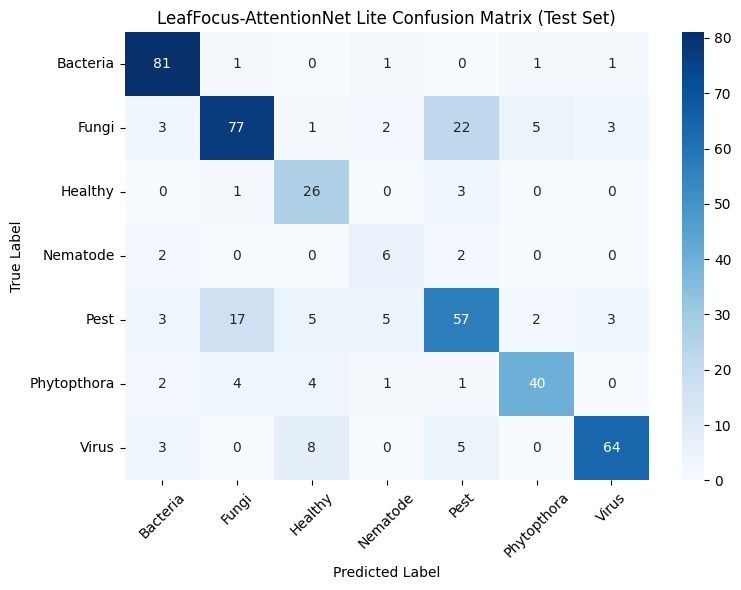

In [ ]:
print("LeafFocus-AttentionNet Lite Classification Report:\n")
print(classification_report(
    test_labels_novel,
    test_preds_novel,
    target_names=class_names,
    digits=4
))

cm_novel = confusion_matrix(test_labels_novel, test_preds_novel)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_novel,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("LeafFocus-AttentionNet Lite Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
results_novel_df = pd.DataFrame({
    "Model": ["LeafFocus-AttentionNet Lite"],
    "Val_Accuracy": [val_acc_novel],
    "Val_Macro_F1": [val_f1_novel],
    "Test_Accuracy": [test_acc_novel],
    "Test_Macro_F1": [test_f1_novel]
})

final_comparison_df = pd.concat(
    [results_b0_df, results_d121_df, results_b2_df, results_novel_df],
    ignore_index=True
)

final_comparison_df = final_comparison_df.sort_values(
    by="Test_Macro_F1", ascending=False
).reset_index(drop=True)

final_comparison_path = "/content/drive/MyDrive/Potato_Project/results/final_comparison_with_novelty.csv"
final_comparison_df.to_csv(final_comparison_path, index=False)

print("Final comparison saved at:")
print(final_comparison_path)
final_comparison_df

Final comparison saved at:
/content/drive/MyDrive/Potato_Project/results/final_comparison_with_novelty.csv


,Model,Val_Accuracy,Val_Macro_F1,Test_Accuracy,Test_Macro_F1
0,EfficientNet-B2,0.798265,0.771704,0.796537,0.749046
1,DenseNet121,0.796095,0.787927,0.781385,0.743734
2,LeafFocus-AttentionNet Lite,0.780911,0.770081,0.759740,0.726399
3,EfficientNet-B0,0.744035,0.713392,0.735931,0.704106


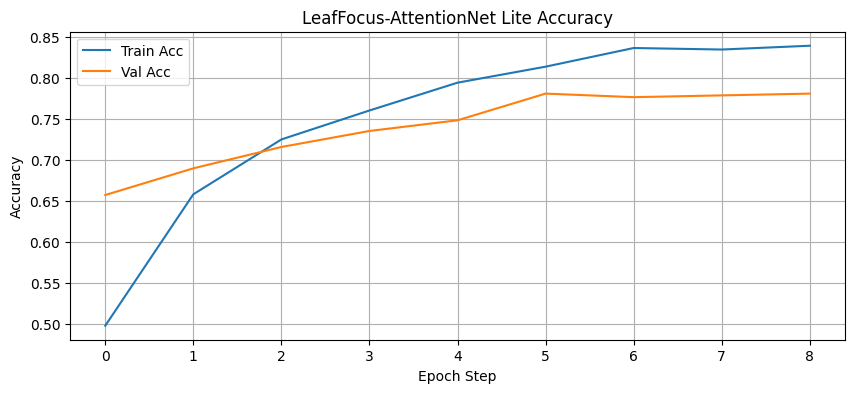

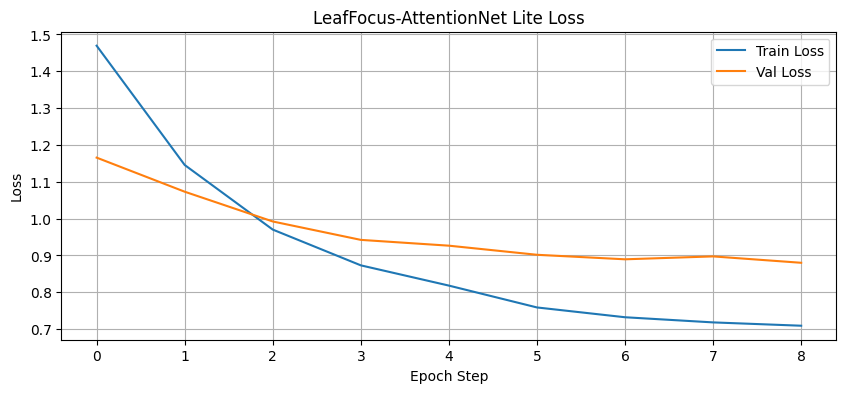

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_novel_df["train_acc"], label="Train Acc")
plt.plot(history_novel_df["val_acc"], label="Val Acc")
plt.title("LeafFocus-AttentionNet Lite Accuracy")
plt.xlabel("Epoch Step")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_novel_df["train_loss"], label="Train Loss")
plt.plot(history_novel_df["val_loss"], label="Val Loss")
plt.title("LeafFocus-AttentionNet Lite Loss")
plt.xlabel("Epoch Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from torchvision import transforms

# B2 TTA transforms
b2_tta_transforms = [
    transforms.Compose([
        transforms.Resize((260, 260)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((260, 260)),
        transforms.Lambda(lambda img: transforms.functional.hflip(img)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((288, 288)),
        transforms.CenterCrop(260),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
]

# DenseNet121 TTA transforms
d121_tta_transforms = [
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Lambda(lambda img: transforms.functional.hflip(img)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
]

print("TTA transforms ready.")

TTA transforms ready.


In [ ]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score

def get_tta_probs(model, dataframe, transform_list, batch_size, device):
    model.eval()
    probs_sum = None

    for t_idx, tta_transform in enumerate(transform_list):
        dataset = PotatoLeafDataset(dataframe, transform=tta_transform)
        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=True if torch.cuda.is_available() else False
        )

        all_probs = []

        with torch.no_grad():
            for images, _ in loader:
                images = images.to(device, non_blocking=True)

                with torch.amp.autocast(device_type=device.type, enabled=torch.cuda.is_available()):
                    outputs = model(images)
                    probs = torch.softmax(outputs, dim=1)

                all_probs.append(probs.cpu().numpy())

        all_probs = np.concatenate(all_probs, axis=0)

        if probs_sum is None:
            probs_sum = all_probs
        else:
            probs_sum += all_probs

        print(f"TTA pass {t_idx+1}/{len(transform_list)} completed.")

    probs_avg = probs_sum / len(transform_list)
    return probs_avg


def evaluate_probs(probs, true_labels):
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(true_labels, preds)
    macro_f1 = f1_score(true_labels, preds, average="macro")
    return acc, macro_f1, preds

In [ ]:
true_test_labels = test_df["label"].values

b2_tta_probs = get_tta_probs(
    model=model_b2_eval,
    dataframe=test_df,
    transform_list=b2_tta_transforms,
    batch_size=32,
    device=device
)

b2_tta_acc, b2_tta_f1, b2_tta_preds = evaluate_probs(b2_tta_probs, true_test_labels)

print("EfficientNet-B2 + TTA")
print("=" * 40)
print(f"Test Accuracy : {b2_tta_acc:.4f}")
print(f"Test Macro F1 : {b2_tta_f1:.4f}")

TTA pass 1/3 completed.
TTA pass 2/3 completed.
TTA pass 3/3 completed.
EfficientNet-B2 + TTA
Test Accuracy : 0.7857
Test Macro F1 : 0.7371


In [ ]:
d121_tta_probs = get_tta_probs(
    model=model_d121_eval,
    dataframe=test_df,
    transform_list=d121_tta_transforms,
    batch_size=32,
    device=device
)

d121_tta_acc, d121_tta_f1, d121_tta_preds = evaluate_probs(d121_tta_probs, true_test_labels)

print("DenseNet121 + TTA")
print("=" * 40)
print(f"Test Accuracy : {d121_tta_acc:.4f}")
print(f"Test Macro F1 : {d121_tta_f1:.4f}")

TTA pass 1/3 completed.
TTA pass 2/3 completed.
TTA pass 3/3 completed.
DenseNet121 + TTA
Test Accuracy : 0.7965
Test Macro F1 : 0.7575


In [ ]:
# B2 ko thora zyada weight de rahe hain kyun ke iska test result best tha
ensemble_probs = (0.60 * b2_tta_probs) + (0.40 * d121_tta_probs)

ensemble_acc, ensemble_f1, ensemble_preds = evaluate_probs(ensemble_probs, true_test_labels)

print("B2 + DenseNet121 Weighted Ensemble")
print("=" * 45)
print(f"Test Accuracy : {ensemble_acc:.4f}")
print(f"Test Macro F1 : {ensemble_f1:.4f}")

B2 + DenseNet121 Weighted Ensemble
Test Accuracy : 0.8074
Test Macro F1 : 0.7508


Ensemble Classification Report:

              precision    recall  f1-score   support

    Bacteria     0.8723    0.9647    0.9162        85
       Fungi     0.7768    0.7699    0.7733       113
     Healthy     0.6857    0.8000    0.7385        30
    Nematode     0.5000    0.3000    0.3750        10
        Pest     0.7386    0.7065    0.7222        92
 Phytopthora     0.9333    0.8077    0.8660        52
       Virus     0.8537    0.8750    0.8642        80

    accuracy                         0.8074       462
   macro avg     0.7658    0.7463    0.7508       462
weighted avg     0.8058    0.8074    0.8047       462



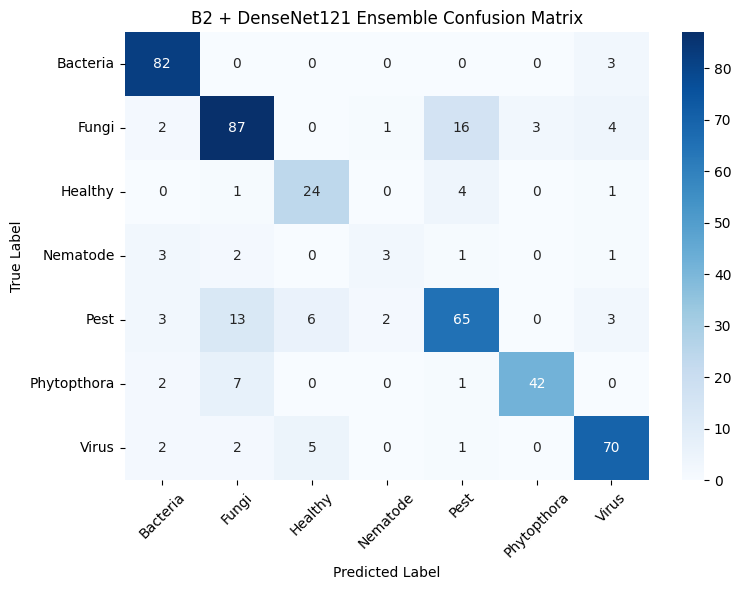

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Ensemble Classification Report:\n")
print(classification_report(
    true_test_labels,
    ensemble_preds,
    target_names=class_names,
    digits=4
))

cm_ensemble = confusion_matrix(true_test_labels, ensemble_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_ensemble,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("B2 + DenseNet121 Ensemble Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
boosted_results_df = pd.DataFrame({
    "Model": [
        "EfficientNet-B2",
        "DenseNet121",
        "EfficientNet-B2 + TTA",
        "DenseNet121 + TTA",
        "B2 + DenseNet121 Ensemble"
    ],
    "Test_Accuracy": [
        test_acc_b2,
        test_acc_d121,
        b2_tta_acc,
        d121_tta_acc,
        ensemble_acc
    ],
    "Test_Macro_F1": [
        test_f1_b2,
        test_f1_d121,
        b2_tta_f1,
        d121_tta_f1,
        ensemble_f1
    ]
})

boosted_results_path = "/content/drive/MyDrive/Potato_Project/results/boosted_results_tta_ensemble.csv"
boosted_results_df.to_csv(boosted_results_path, index=False)

print("Boosted results saved at:")
print(boosted_results_path)
boosted_results_df

Boosted results saved at:
/content/drive/MyDrive/Potato_Project/results/boosted_results_tta_ensemble.csv


,Model,Test_Accuracy,Test_Macro_F1
0,EfficientNet-B2,0.796537,0.749046
1,DenseNet121,0.781385,0.743734
2,EfficientNet-B2 + TTA,0.785714,0.737065
3,DenseNet121 + TTA,0.796537,0.757531
4,B2 + DenseNet121 Ensemble,0.807359,0.750771


In [ ]:
train_bin_df = train_df.copy()
val_bin_df   = val_df.copy()
test_bin_df  = test_df.copy()

def to_binary_class(x):
    return "Healthy" if x == "Healthy" else "Diseased"

train_bin_df["binary_class"] = train_bin_df["class_name"].apply(to_binary_class)
val_bin_df["binary_class"]   = val_bin_df["class_name"].apply(to_binary_class)
test_bin_df["binary_class"]  = test_bin_df["class_name"].apply(to_binary_class)

binary_class_to_idx = {"Healthy": 0, "Diseased": 1}
binary_idx_to_class = {0: "Healthy", 1: "Diseased"}

train_bin_df["label"] = train_bin_df["binary_class"].map(binary_class_to_idx)
val_bin_df["label"]   = val_bin_df["binary_class"].map(binary_class_to_idx)
test_bin_df["label"]  = test_bin_df["binary_class"].map(binary_class_to_idx)

print("Binary mapping:", binary_class_to_idx)
print("\nTrain binary distribution:")
print(train_bin_df["binary_class"].value_counts())
print("\nVal binary distribution:")
print(val_bin_df["binary_class"].value_counts())
print("\nTest binary distribution:")
print(test_bin_df["binary_class"].value_counts())

Binary mapping: {'Healthy': 0, 'Diseased': 1}

Train binary distribution:
binary_class
Diseased    2012
Healthy      141
Name: count, dtype: int64

Val binary distribution:
binary_class
Diseased    431
Healthy      30
Name: count, dtype: int64

Test binary distribution:
binary_class
Diseased    432
Healthy      30
Name: count, dtype: int64


In [ ]:
BINARY_SPLIT_DIR = "/content/drive/MyDrive/Potato_Project/binary_splits"
os.makedirs(BINARY_SPLIT_DIR, exist_ok=True)

train_bin_df.to_csv(f"{BINARY_SPLIT_DIR}/train_binary.csv", index=False)
val_bin_df.to_csv(f"{BINARY_SPLIT_DIR}/val_binary.csv", index=False)
test_bin_df.to_csv(f"{BINARY_SPLIT_DIR}/test_binary.csv", index=False)

print("Binary splits saved in:", BINARY_SPLIT_DIR)

Binary splits saved in: /content/drive/MyDrive/Potato_Project/binary_splits


In [ ]:
IMG_SIZE_BIN = 300
BATCH_SIZE_BIN = 24
NUM_WORKERS_BIN = 0
PIN_MEMORY_BIN = True if torch.cuda.is_available() else False

num_classes_bin = 2
binary_class_names = ["Healthy", "Diseased"]

print("IMG_SIZE_BIN   :", IMG_SIZE_BIN)
print("BATCH_SIZE_BIN :", BATCH_SIZE_BIN)
print("Classes        :", binary_class_names)

IMG_SIZE_BIN   : 300
BATCH_SIZE_BIN : 24
Classes        : ['Healthy', 'Diseased']


In [ ]:
train_transform_bin = transforms.Compose([
    transforms.RandomResizedCrop(
        IMG_SIZE_BIN,
        scale=(0.80, 1.0),
        ratio=(0.90, 1.10)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.18,
        contrast=0.18,
        saturation=0.18,
        hue=0.04
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform_bin = transforms.Compose([
    transforms.Resize((IMG_SIZE_BIN, IMG_SIZE_BIN)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Binary transforms ready.")

Binary transforms ready.


In [ ]:
train_dataset_bin = PotatoLeafDataset(train_bin_df, transform=train_transform_bin)
val_dataset_bin   = PotatoLeafDataset(val_bin_df, transform=val_test_transform_bin)
test_dataset_bin  = PotatoLeafDataset(test_bin_df, transform=val_test_transform_bin)

train_loader_bin = DataLoader(
    train_dataset_bin,
    batch_size=BATCH_SIZE_BIN,
    shuffle=True,
    num_workers=NUM_WORKERS_BIN,
    pin_memory=PIN_MEMORY_BIN
)

val_loader_bin = DataLoader(
    val_dataset_bin,
    batch_size=BATCH_SIZE_BIN,
    shuffle=False,
    num_workers=NUM_WORKERS_BIN,
    pin_memory=PIN_MEMORY_BIN
)

test_loader_bin = DataLoader(
    test_dataset_bin,
    batch_size=BATCH_SIZE_BIN,
    shuffle=False,
    num_workers=NUM_WORKERS_BIN,
    pin_memory=PIN_MEMORY_BIN
)

print("Binary dataloaders ready.")
print("Train batches:", len(train_loader_bin))
print("Val batches  :", len(val_loader_bin))
print("Test batches :", len(test_loader_bin))

Binary dataloaders ready.
Train batches: 90
Val batches  : 20
Test batches : 20


In [ ]:
train_bin_counts = train_bin_df["label"].value_counts().sort_index().values.astype(np.float32)

class_weights_bin = 1.0 / np.sqrt(train_bin_counts)
class_weights_bin = class_weights_bin / class_weights_bin.mean()

class_weights_bin_tensor = torch.tensor(
    class_weights_bin, dtype=torch.float32
).to(device)

print("Binary class counts :", train_bin_counts)
print("Binary class weights:", class_weights_bin)

Binary class counts : [ 141. 2012.]
Binary class weights: [1.5813711  0.41862902]


In [ ]:
MODEL_SAVE_DIR_BIN = "/content/drive/MyDrive/Potato_Project/binary_b2"
os.makedirs(MODEL_SAVE_DIR_BIN, exist_ok=True)

BEST_BIN_PATH = os.path.join(MODEL_SAVE_DIR_BIN, "best_binary_efficientnet_b2.pth")
HISTORY_BIN_PATH = os.path.join(MODEL_SAVE_DIR_BIN, "history_binary_b2.csv")

print("Binary model save dir:", MODEL_SAVE_DIR_BIN)

Binary model save dir: /content/drive/MyDrive/Potato_Project/binary_b2


In [ ]:
model_bin = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)

in_features = model_bin.classifier[1].in_features
model_bin.classifier = nn.Sequential(
    nn.Dropout(0.35),
    nn.Linear(in_features, num_classes_bin)
)

for param in model_bin.features.parameters():
    param.requires_grad = False

model_bin = model_bin.to(device)

print(model_bin)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
criterion_bin = nn.CrossEntropyLoss(
    weight=class_weights_bin_tensor,
    label_smoothing=0.03
)

optimizer_bin = torch.optim.AdamW(
    model_bin.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scaler_bin = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

history_bin = {
    "phase": [],
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "lr": []
}

best_val_f1_bin = 0.0
best_val_acc_bin = 0.0
best_epoch_bin = -1

print("Binary training setup ready.")

Binary training setup ready.


In [ ]:
EPOCHS_BIN_PHASE1 = 2

for epoch in range(EPOCHS_BIN_PHASE1):
    print("=" * 60)
    print(f"Binary B2 Phase 1 Epoch {epoch+1}/{EPOCHS_BIN_PHASE1}")

    train_loss, train_acc = train_one_epoch(
        model_bin, train_loader_bin, criterion_bin, optimizer_bin, scaler_bin, device
    )

    val_loss, val_acc, val_f1, _, _ = validate_one_epoch(
        model_bin, val_loader_bin, criterion_bin, device
    )

    current_lr = optimizer_bin.param_groups[0]["lr"]

    history_bin["phase"].append("phase1_head_only")
    history_bin["epoch"].append(epoch + 1)
    history_bin["train_loss"].append(train_loss)
    history_bin["train_acc"].append(train_acc)
    history_bin["val_loss"].append(val_loss)
    history_bin["val_acc"].append(val_acc)
    history_bin["val_f1"].append(val_f1)
    history_bin["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1_bin:
        best_val_f1_bin = val_f1
        best_val_acc_bin = val_acc
        best_epoch_bin = epoch + 1
        torch.save(model_bin.state_dict(), BEST_BIN_PATH)
        print("Best binary model saved!")

print("\nBinary Phase 1 completed.")
print(f"Best Val Acc: {best_val_acc_bin:.4f}")
print(f"Best Val F1 : {best_val_f1_bin:.4f}")
print(f"Best Epoch  : {best_epoch_bin}")

Binary B2 Phase 1 Epoch 1/2


Training:   0%|          | 0/90 [00:00<?, ?it/s]

Validation:   0%|          | 0/20 [00:00<?, ?it/s]

Train Loss: 0.4732 | Train Acc: 0.9299
Val Loss  : 0.4240 | Val Acc  : 0.9197 | Val F1: 0.6938
Best binary model saved!
Binary B2 Phase 1 Epoch 2/2


Training:   0%|          | 0/90 [00:00<?, ?it/s]

Validation:   0%|          | 0/20 [00:00<?, ?it/s]

Train Loss: 0.4006 | Train Acc: 0.9327
Val Loss  : 0.4027 | Val Acc  : 0.9067 | Val F1: 0.7271
Best binary model saved!

Binary Phase 1 completed.
Best Val Acc: 0.9067
Best Val F1 : 0.7271
Best Epoch  : 2


In [ ]:
model_bin.load_state_dict(torch.load(BEST_BIN_PATH, map_location=device))

for param in model_bin.features.parameters():
    param.requires_grad = True

optimizer_bin = torch.optim.AdamW([
    {"params": model_bin.features.parameters(), "lr": 2e-5},
    {"params": model_bin.classifier.parameters(), "lr": 1e-4}
], weight_decay=1e-4)

scheduler_bin = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_bin,
    T_max=8
)

EPOCHS_BIN_PHASE2 = 8
PATIENCE_BIN = 3
patience_counter_bin = 0

print("Binary Phase 2 ready.")

Binary Phase 2 ready.


In [ ]:
for epoch in range(EPOCHS_BIN_PHASE2):
    print("=" * 60)
    print(f"Binary B2 Phase 2 Epoch {epoch+1}/{EPOCHS_BIN_PHASE2}")

    train_loss, train_acc = train_one_epoch(
        model_bin, train_loader_bin, criterion_bin, optimizer_bin, scaler_bin, device
    )

    val_loss, val_acc, val_f1, _, _ = validate_one_epoch(
        model_bin, val_loader_bin, criterion_bin, device
    )

    scheduler_bin.step()
    current_lr = optimizer_bin.param_groups[0]["lr"]

    history_bin["phase"].append("phase2_full_finetune")
    history_bin["epoch"].append(epoch + 1)
    history_bin["train_loss"].append(train_loss)
    history_bin["train_acc"].append(train_acc)
    history_bin["val_loss"].append(val_loss)
    history_bin["val_acc"].append(val_acc)
    history_bin["val_f1"].append(val_f1)
    history_bin["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1_bin:
        best_val_f1_bin = val_f1
        best_val_acc_bin = val_acc
        best_epoch_bin = epoch + 1
        patience_counter_bin = 0
        torch.save(model_bin.state_dict(), BEST_BIN_PATH)
        print("Best binary model updated and saved!")
    else:
        patience_counter_bin += 1
        print(f"No improvement. Patience: {patience_counter_bin}/{PATIENCE_BIN}")

    if patience_counter_bin >= PATIENCE_BIN:
        print("Early stopping triggered.")
        break

print("\nBinary Phase 2 completed.")
print(f"Best Overall Val Acc: {best_val_acc_bin:.4f}")
print(f"Best Overall Val F1 : {best_val_f1_bin:.4f}")
print(f"Best Overall Epoch  : {best_epoch_bin}")

Binary B2 Phase 2 Epoch 1/8


Training:   0%|          | 0/90 [00:00<?, ?it/s]

Validation:   0%|          | 0/20 [00:00<?, ?it/s]

Train Loss: 0.3692 | Train Acc: 0.9354
Val Loss  : 0.3558 | Val Acc  : 0.9306 | Val F1: 0.7706
Best binary model updated and saved!
Binary B2 Phase 2 Epoch 2/8


Training:   0%|          | 0/90 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/20 [00:00<?, ?it/s]

Train Loss: 0.2565 | Train Acc: 0.9791
Val Loss  : 0.3009 | Val Acc  : 0.9501 | Val F1: 0.8477
Best binary model updated and saved!
Binary B2 Phase 2 Epoch 8/8


Training:   0%|          | 0/90 [00:00<?, ?it/s]

Validation:   0%|          | 0/20 [00:00<?, ?it/s]

Train Loss: 0.2586 | Train Acc: 0.9791
Val Loss  : 0.2987 | Val Acc  : 0.9523 | Val F1: 0.8528
Best binary model updated and saved!

Binary Phase 2 completed.
Best Overall Val Acc: 0.9523
Best Overall Val F1 : 0.8528
Best Overall Epoch  : 8


In [ ]:
history_bin_df = pd.DataFrame(history_bin)
history_bin_df.to_csv(HISTORY_BIN_PATH, index=False)

model_bin_eval = models.efficientnet_b2(weights=None)

in_features = model_bin_eval.classifier[1].in_features
model_bin_eval.classifier = nn.Sequential(
    nn.Dropout(0.35),
    nn.Linear(in_features, num_classes_bin)
)

model_bin_eval.load_state_dict(torch.load(BEST_BIN_PATH, map_location=device))
model_bin_eval = model_bin_eval.to(device)
model_bin_eval.eval()

val_acc_bin, val_f1_bin, val_labels_bin, val_preds_bin = evaluate_model(
    model_bin_eval, val_loader_bin, device
)

test_acc_bin, test_f1_bin, test_labels_bin, test_preds_bin = evaluate_model(
    model_bin_eval, test_loader_bin, device
)

print("Binary EfficientNet-B2 Final Evaluation")
print("=" * 50)
print(f"Validation Accuracy : {val_acc_bin:.4f}")
print(f"Validation Macro F1 : {val_f1_bin:.4f}")
print(f"Test Accuracy       : {test_acc_bin:.4f}")
print(f"Test Macro F1       : {test_f1_bin:.4f}")

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

Binary EfficientNet-B2 Final Evaluation
Validation Accuracy : 0.9523
Validation Macro F1 : 0.8528
Test Accuracy       : 0.9524
Test Macro F1       : 0.8495


Binary Classification Report:

              precision    recall  f1-score   support

     Healthy     0.5800    0.9667    0.7250        30
    Diseased     0.9976    0.9514    0.9739       432

    accuracy                         0.9524       462
   macro avg     0.7888    0.9590    0.8495       462
weighted avg     0.9705    0.9524    0.9578       462



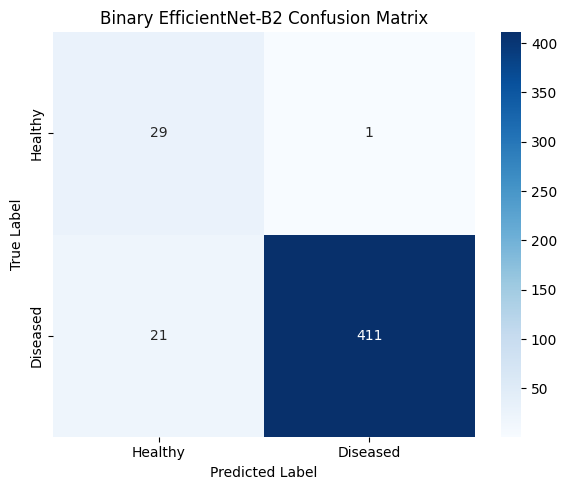

In [ ]:
print("Binary Classification Report:\n")
print(classification_report(
    test_labels_bin,
    test_preds_bin,
    target_names=binary_class_names,
    digits=4
))

cm_bin = confusion_matrix(test_labels_bin, test_preds_bin)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_bin,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=binary_class_names,
    yticklabels=binary_class_names
)
plt.title("Binary EfficientNet-B2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
binary_tta_transforms = [
    transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.Lambda(lambda img: transforms.functional.hflip(img)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((340, 340)),
        transforms.CenterCrop(300),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
]

true_test_labels_bin = test_bin_df["label"].values

bin_tta_probs = get_tta_probs(
    model=model_bin_eval,
    dataframe=test_bin_df,
    transform_list=binary_tta_transforms,
    batch_size=24,
    device=device
)

bin_tta_acc, bin_tta_f1, bin_tta_preds = evaluate_probs(bin_tta_probs, true_test_labels_bin)

print("Binary EfficientNet-B2 + TTA")
print("=" * 40)
print(f"Test Accuracy : {bin_tta_acc:.4f}")
print(f"Test Macro F1 : {bin_tta_f1:.4f}")

TTA pass 1/3 completed.
TTA pass 2/3 completed.
TTA pass 3/3 completed.
Binary EfficientNet-B2 + TTA
Test Accuracy : 0.9567
Test Macro F1 : 0.8566


In [ ]:
binary_results_df = pd.DataFrame({
    "Model": [
        "Binary EfficientNet-B2",
        "Binary EfficientNet-B2 + TTA"
    ],
    "Test_Accuracy": [
        test_acc_bin,
        bin_tta_acc
    ],
    "Test_Macro_F1": [
        test_f1_bin,
        bin_tta_f1
    ]
})

binary_results_path = "/content/drive/MyDrive/Potato_Project/results/binary_results_b2.csv"
binary_results_df.to_csv(binary_results_path, index=False)

print("Binary results saved at:")
print(binary_results_path)
binary_results_df

Binary results saved at:
/content/drive/MyDrive/Potato_Project/results/binary_results_b2.csv


,Model,Test_Accuracy,Test_Macro_F1
0,Binary EfficientNet-B2,0.952381,0.849467
1,Binary EfficientNet-B2 + TTA,0.956710,0.856629


In [ ]:
final_project_summary_df = pd.DataFrame({
    "Experiment": [
        "7-Class EfficientNet-B0",
        "7-Class DenseNet121",
        "7-Class EfficientNet-B2",
        "7-Class LeafFocus-AttentionNet Lite",
        "7-Class B2 + DenseNet121 Ensemble",
        "Binary EfficientNet-B2",
        "Binary EfficientNet-B2 + TTA"
    ],
    "Task_Type": [
        "7-Class",
        "7-Class",
        "7-Class",
        "7-Class",
        "7-Class",
        "Binary",
        "Binary"
    ],
    "Test_Accuracy": [
        test_acc_b0,
        test_acc_d121,
        test_acc_b2,
        test_acc_novel,
        ensemble_acc,
        test_acc_bin,
        bin_tta_acc
    ],
    "Test_Macro_F1": [
        test_f1_b0,
        test_f1_d121,
        test_f1_b2,
        test_f1_novel,
        ensemble_f1,
        test_f1_bin,
        bin_tta_f1
    ]
})

final_project_summary_path = "/content/drive/MyDrive/Potato_Project/results/final_project_summary.csv"
final_project_summary_df.to_csv(final_project_summary_path, index=False)

print("Final summary saved at:")
print(final_project_summary_path)
final_project_summary_df

Final summary saved at:
/content/drive/MyDrive/Potato_Project/results/final_project_summary.csv


,Experiment,Task_Type,Test_Accuracy,Test_Macro_F1
0,7-Class EfficientNet-B0,7-Class,0.735931,0.704106
1,7-Class DenseNet121,7-Class,0.781385,0.743734
2,7-Class EfficientNet-B2,7-Class,0.796537,0.749046
3,7-Class LeafFocus-AttentionNet Lite,7-Class,0.759740,0.726399
4,7-Class B2 + DenseNet121 Ensemble,7-Class,0.807359,0.750771
5,Binary EfficientNet-B2,Binary,0.952381,0.849467
6,Binary EfficientNet-B2 + TTA,Binary,0.956710,0.856629


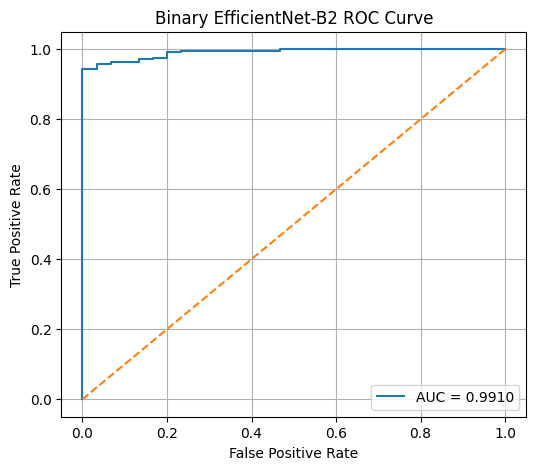

ROC-AUC: 0.9910493827160494


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Binary model probabilities
test_bin_dataset_eval = PotatoLeafDataset(test_bin_df, transform=val_test_transform_bin)
test_bin_loader_eval = DataLoader(
    test_bin_dataset_eval,
    batch_size=24,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

all_probs_bin = []
all_labels_bin = []

model_bin_eval.eval()
with torch.no_grad():
    for images, labels in test_bin_loader_eval:
        images = images.to(device)
        outputs = model_bin_eval(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]   # Diseased probability

        all_probs_bin.extend(probs.cpu().numpy())
        all_labels_bin.extend(labels.cpu().numpy())

all_probs_bin = np.array(all_probs_bin)
all_labels_bin = np.array(all_labels_bin)

fpr, tpr, _ = roc_curve(all_labels_bin, all_probs_bin)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Binary EfficientNet-B2 ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print("ROC-AUC:", roc_auc)

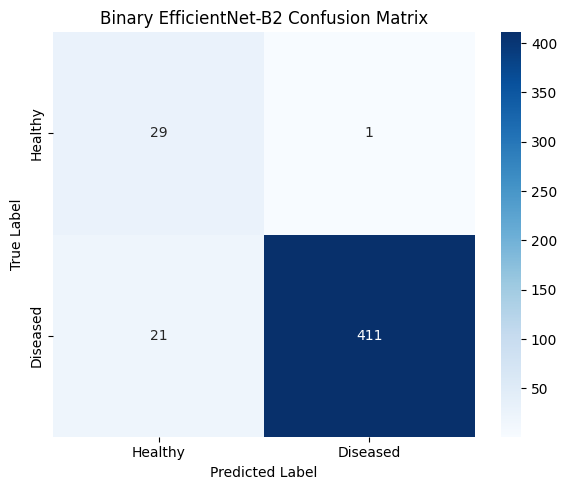

Confusion matrix image saved at:
/content/drive/MyDrive/Potato_Project/results/binary_confusion_matrix.png


In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_bin,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=binary_class_names,
    yticklabels=binary_class_names
)
plt.title("Binary EfficientNet-B2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

cm_save_path = "/content/drive/MyDrive/Potato_Project/results/binary_confusion_matrix.png"
plt.savefig(cm_save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix image saved at:")
print(cm_save_path)

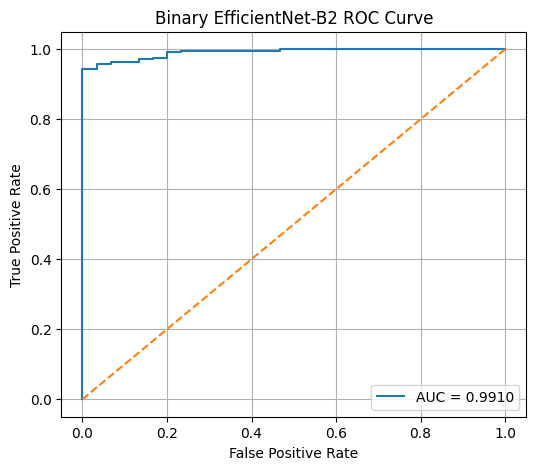

ROC curve image saved at:
/content/drive/MyDrive/Potato_Project/results/binary_roc_curve.png


In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Binary EfficientNet-B2 ROC Curve")
plt.legend()
plt.grid(True)

roc_save_path = "/content/drive/MyDrive/Potato_Project/results/binary_roc_curve.png"
plt.savefig(roc_save_path, dpi=300, bbox_inches="tight")
plt.show()

print("ROC curve image saved at:")
print(roc_save_path)

In [ ]:
final_text = f"""
FINAL BEST RESULT
=================
Model: Binary EfficientNet-B2 + TTA
Task: Healthy vs Diseased
Validation Accuracy: {val_acc_bin:.4f}
Validation Macro F1: {val_f1_bin:.4f}
Test Accuracy: {bin_tta_acc:.4f}
Test Macro F1: {bin_tta_f1:.4f}

Important Note:
This 95.67% result belongs to BINARY classification only.
It should not be reported as 7-class potato disease classification accuracy.
"""

final_note_path = "/content/drive/MyDrive/Potato_Project/results/final_best_result.txt"
with open(final_note_path, "w") as f:
    f.write(final_text)

print("Final text summary saved at:")
print(final_note_path)
print(final_text)

Final text summary saved at:
/content/drive/MyDrive/Potato_Project/results/final_best_result.txt

FINAL BEST RESULT
Model: Binary EfficientNet-B2 + TTA
Task: Healthy vs Diseased
Validation Accuracy: 0.9523
Validation Macro F1: 0.8528
Test Accuracy: 0.9567
Test Macro F1: 0.8566

Important Note:
This 95.67% result belongs to BINARY classification only.
It should not be reported as 7-class potato disease classification accuracy.



Reconstructed training history saved at:
/content/drive/MyDrive/Potato_Project/results/binary_training_history_reconstructed.csv
     phase  epoch_overall  epoch_in_phase  train_loss  train_acc  val_loss  \
0  Phase 1              1               1      0.4732     0.9299    0.4240   
1  Phase 1              2               2      0.4006     0.9327    0.4027   
2  Phase 2              3               1      0.3692     0.9354    0.3558   
3  Phase 2              4               2      0.3151     0.9633    0.3363   
4  Phase 2              5               3      0.3055     0.9610    0.3217   
5  Phase 2              6               4      0.2969     0.9638    0.3148   
6  Phase 2              7               5      0.2806     0.9703    0.3069   
7  Phase 2              8               6      0.2697     0.9740    0.3005   
8  Phase 2              9               7      0.2565     0.9791    0.3009   
9  Phase 2             10               8      0.2586     0.9791    0.2987   

   val_acc  

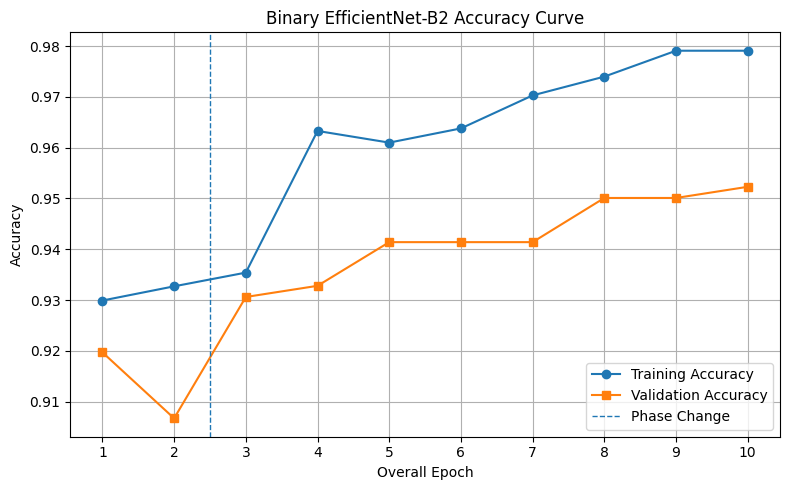

Accuracy curve saved at:
/content/drive/MyDrive/Potato_Project/results/binary_accuracy_curve.png


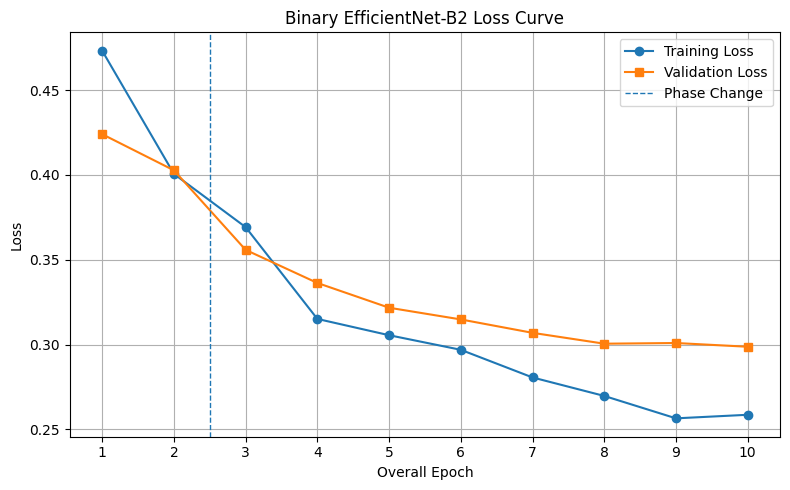

Loss curve saved at:
/content/drive/MyDrive/Potato_Project/results/binary_loss_curve.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# SAVE PATH
# =========================
RESULTS_DIR = "/content/drive/MyDrive/Potato_Project/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# =========================
# RECONSTRUCTED TRAINING HISTORY
# Phase 1 = 2 epochs
# Phase 2 = 8 epochs
# Overall total = 10 epochs
# =========================
history_data = {
    "phase": [
        "Phase 1", "Phase 1",
        "Phase 2", "Phase 2", "Phase 2", "Phase 2",
        "Phase 2", "Phase 2", "Phase 2", "Phase 2"
    ],
    "epoch_overall": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "epoch_in_phase": [1, 2, 1, 2, 3, 4, 5, 6, 7, 8],

    "train_loss": [0.4732, 0.4006, 0.3692, 0.3151, 0.3055, 0.2969, 0.2806, 0.2697, 0.2565, 0.2586],
    "train_acc":  [0.9299, 0.9327, 0.9354, 0.9633, 0.9610, 0.9638, 0.9703, 0.9740, 0.9791, 0.9791],

    "val_loss":   [0.4240, 0.4027, 0.3558, 0.3363, 0.3217, 0.3148, 0.3069, 0.3005, 0.3009, 0.2987],
    "val_acc":    [0.9197, 0.9067, 0.9306, 0.9328, 0.9414, 0.9414, 0.9414, 0.9501, 0.9501, 0.9523],
    "val_f1":     [0.6938, 0.7271, 0.7706, 0.8033, 0.8250, 0.8287, 0.8287, 0.8444, 0.8477, 0.8528],
}

df_history = pd.DataFrame(history_data)

# CSV save
csv_path = os.path.join(RESULTS_DIR, "binary_training_history_reconstructed.csv")
df_history.to_csv(csv_path, index=False)

print("Reconstructed training history saved at:")
print(csv_path)
print(df_history)

# =========================
# FIGURE 3: ACCURACY CURVE
# =========================
plt.figure(figsize=(8, 5))
plt.plot(df_history["epoch_overall"], df_history["train_acc"], marker='o', label="Training Accuracy")
plt.plot(df_history["epoch_overall"], df_history["val_acc"], marker='s', label="Validation Accuracy")

# Optional phase separator
plt.axvline(x=2.5, linestyle='--', linewidth=1, label="Phase Change")

plt.title("Binary EfficientNet-B2 Accuracy Curve")
plt.xlabel("Overall Epoch")
plt.ylabel("Accuracy")
plt.xticks(df_history["epoch_overall"])
plt.legend()
plt.grid(True)
plt.tight_layout()

acc_path = os.path.join(RESULTS_DIR, "binary_accuracy_curve.png")
plt.savefig(acc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy curve saved at:")
print(acc_path)

# =========================
# FIGURE 4: LOSS CURVE
# =========================
plt.figure(figsize=(8, 5))
plt.plot(df_history["epoch_overall"], df_history["train_loss"], marker='o', label="Training Loss")
plt.plot(df_history["epoch_overall"], df_history["val_loss"], marker='s', label="Validation Loss")

# Optional phase separator
plt.axvline(x=2.5, linestyle='--', linewidth=1, label="Phase Change")

plt.title("Binary EfficientNet-B2 Loss Curve")
plt.xlabel("Overall Epoch")
plt.ylabel("Loss")
plt.xticks(df_history["epoch_overall"])
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_path = os.path.join(RESULTS_DIR, "binary_loss_curve.png")
plt.savefig(loss_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss curve saved at:")
print(loss_path)